In [8]:
#LOAD DATA AND PREPROCESSING
import pandas as pd
import numpy as np
import ast

# === STEP 1: LOAD & RENAME ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)

# === STEP 2: SUBSET AND CLEAN ===
selected_columns = df[[
    'node', '_wkshell', 'Y2H_wkshell',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'DeepTMHMM_class', 'signalP_trimmed_sequence',
    'IDR_count', 'N_aa_disordered', 'disorder_fraction',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00',
    'mean_plddt', 'L', 
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy',
    'Christiano_degradation_rate(min-1)', 'Villen_halflife_min',
    'mean_molecules_per_cell', 'median_molecules_per_cell', 'log2_TE',
    'interacting_chaperones', 'in_complex', 'Pfam_Ndomains', 
    'essential',  
    'sequence', 'structure_exists', 'sequence_matches_structure', 'meltome-melting-point', 'meltome-AUC', 'meltome-fit-R2'
       
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chpaerone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = selected_columns[selected_columns["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
selected_columns = selected_columns[selected_columns["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {selected_columns.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
selected_columns = selected_columns[selected_columns["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {selected_columns.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 82 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   Y2H_wkshell                            1465 non-null   float64
 3   MS_degree_centrality                   3927 non-null   float64
 4   MS_betweenness_centrality              3927 non-null   float64
 5   MS_eigenvector_centrality              3927 non-null   float64
 6   MS_closeness_centrality                3927 non-null   float64
 7   MS_load_centrality                     3927 non-null   float64
 8   MS_pagerank                            3927 non-null   float64
 9   MS_information_centrality              3927 non-null   float64
 10  Y2H_degree_centrality                  1465 non-null   float64
 11  Y2H_

In [9]:
# Assuming selected_columns is already loaded/defined here
# Filter: Remove low pLDDT and TMD/SP proteins
filtered_df = selected_columns[
    (selected_columns['mean_plddt'] >= 50) &
    (~selected_columns['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Optional: Print stats to verify
print(f"Original rows: {len(selected_columns)}")
print(f"Filtered rows: {len(filtered_df)}")

Original rows: 3859
Filtered rows: 3209


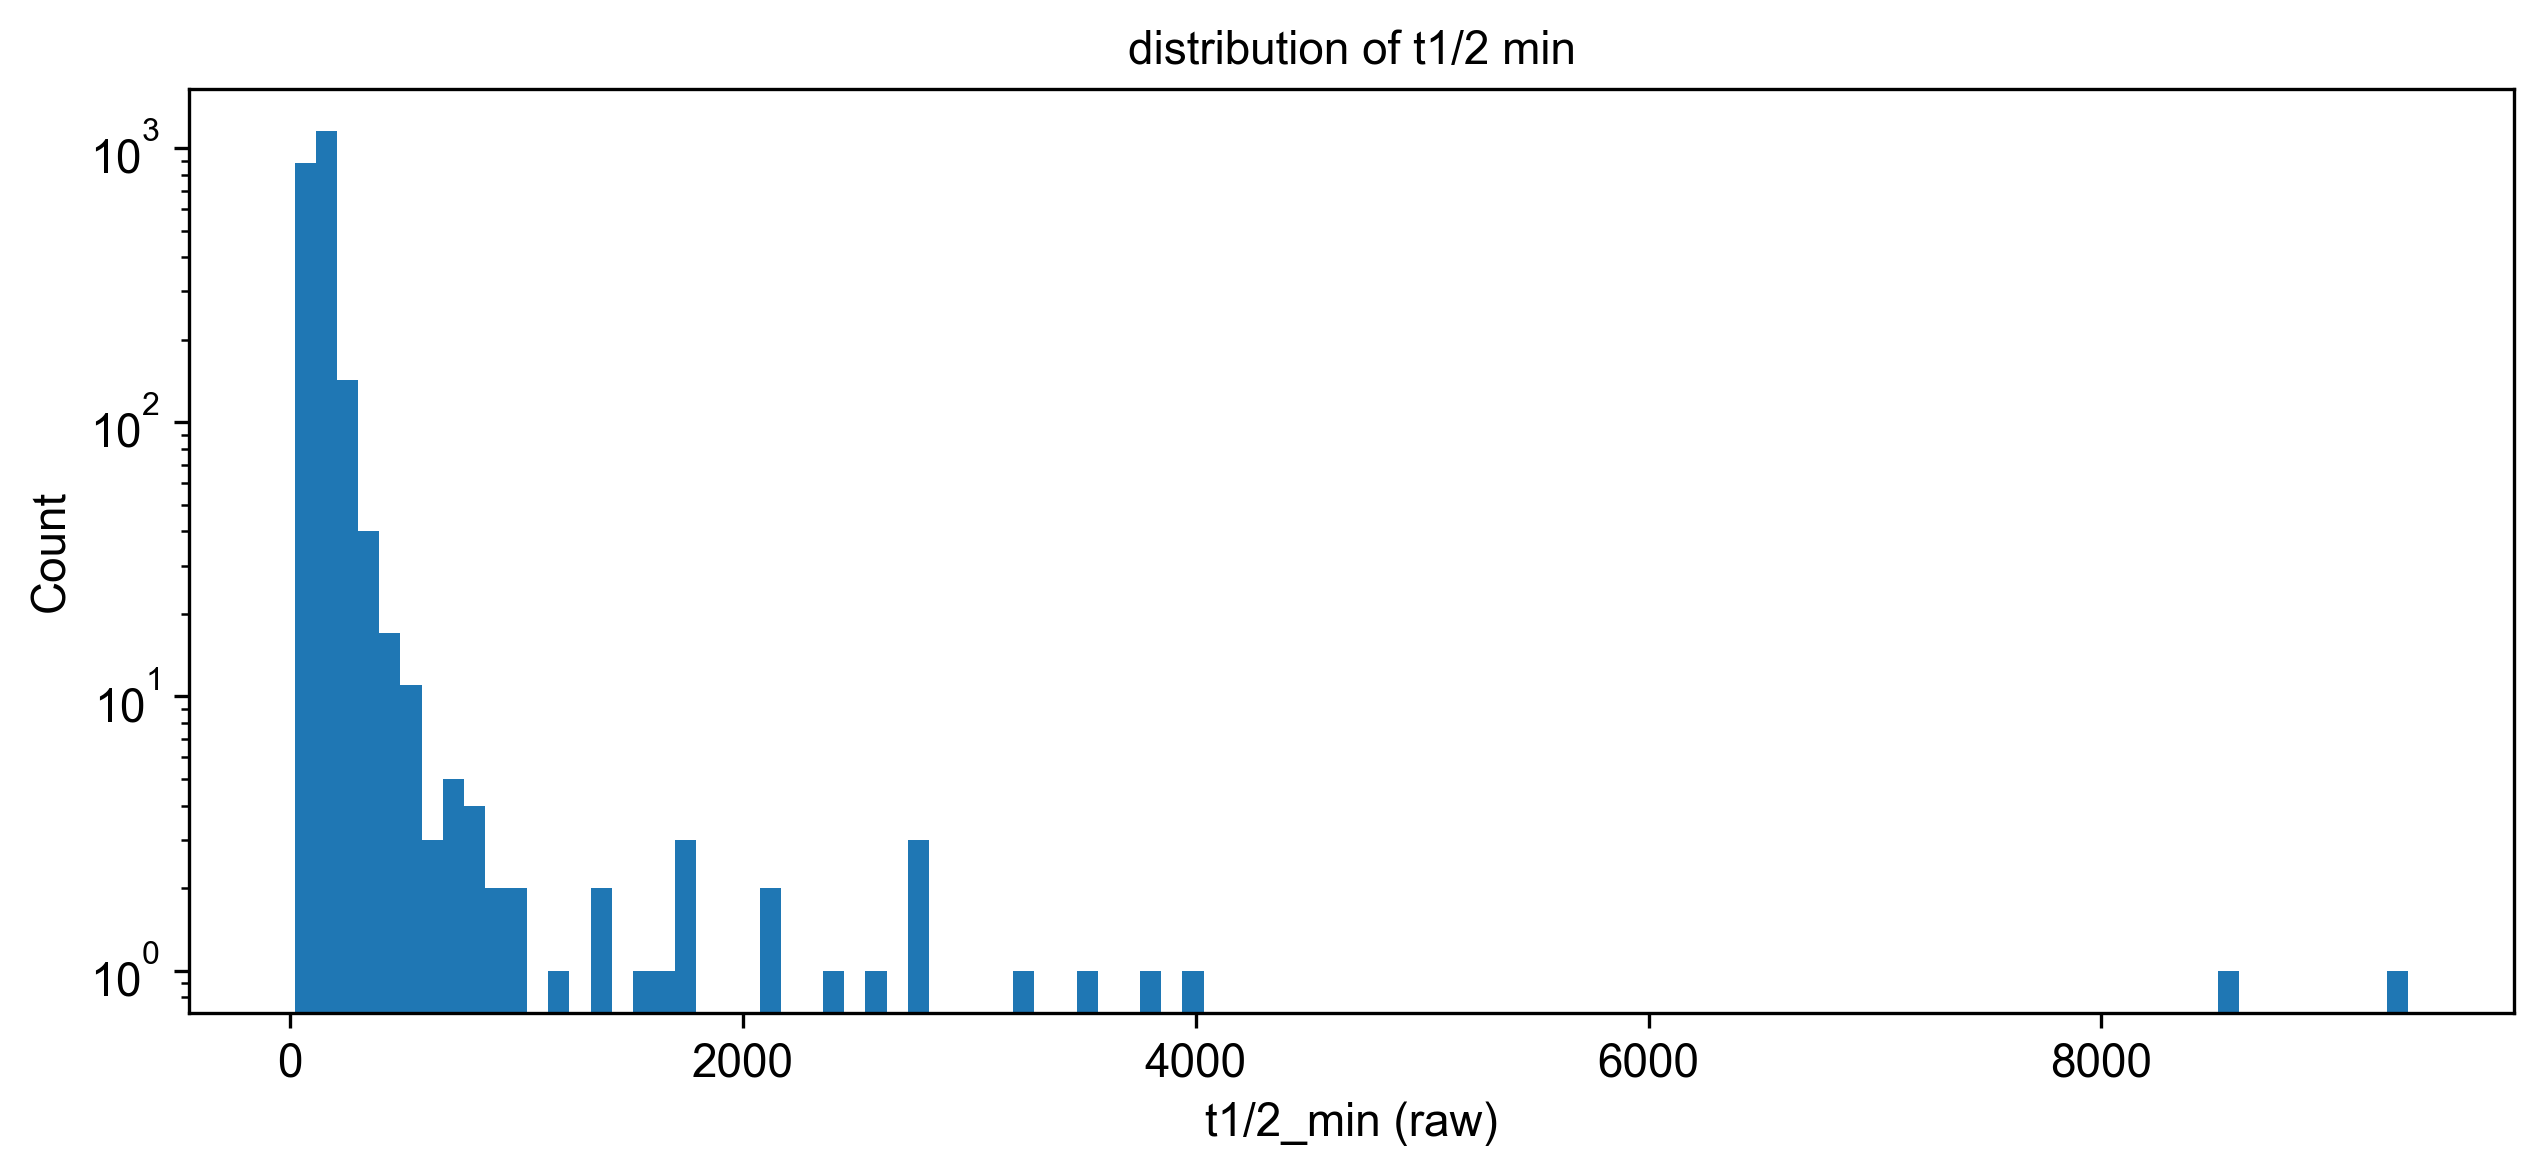

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(filtered_df['Villen_halflife_min'].dropna(), bins=100, log=True)
plt.xlabel('t1/2_min (raw)')
plt.ylabel('Count')
plt.title('distribution of t1/2 min')
plt.show()


=== Percentage Differences for IPMS Degree Centrality ===
Hubs IPMS are -31.53% greater than Non-hubs IPMS (medians: 91.20 vs 133.20)

=== Mann–Whitney U Tests (log-transformed) for IPMS Degree Centrality ===
IPMS Hubs vs Non-hubs: U=179325.00, p=4.678e-37, n1=326, n2=1962

=== Kolmogorov-Smirnov Tests (log-transformed) for IPMS Degree Centrality ===
IPMS Hubs vs Non-hubs: KS=0.42, p=7.755e-45, n1=326, n2=1962


/tmp/ipykernel_837311/2959476.py:60: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)



=== Percentage Differences for Y2H Degree Centrality ===
Hubs Y2H are 11.14% greater than Non-hubs Y2H (medians: 146.70 vs 132.00)

=== Mann–Whitney U Tests (log-transformed) for Y2H Degree Centrality ===
Y2H Hubs vs Non-hubs: U=53864.50, p=0.001626, n1=108, n2=841

=== Kolmogorov-Smirnov Tests (log-transformed) for Y2H Degree Centrality ===
Y2H Hubs vs Non-hubs: KS=0.17, p=0.005601, n1=108, n2=841

=== Percentage Differences for IPMS Betweenness Centrality ===
Hubs IPMS are -2.80% greater than Non-hubs IPMS (medians: 124.80 vs 128.40)

=== Mann–Whitney U Tests (log-transformed) for IPMS Betweenness Centrality ===
IPMS Hubs vs Non-hubs: U=270207.50, p=0.1239, n1=286, n2=2002

=== Kolmogorov-Smirnov Tests (log-transformed) for IPMS Betweenness Centrality ===
IPMS Hubs vs Non-hubs: KS=0.07, p=0.1853, n1=286, n2=2002


/tmp/ipykernel_837311/2959476.py:60: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_837311/2959476.py:60: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)



=== Percentage Differences for Y2H Betweenness Centrality ===
Hubs Y2H are 9.73% greater than Non-hubs Y2H (medians: 145.50 vs 132.60)

=== Mann–Whitney U Tests (log-transformed) for Y2H Betweenness Centrality ===
Y2H Hubs vs Non-hubs: U=45552.00, p=0.01415, n1=92, n2=857

=== Kolmogorov-Smirnov Tests (log-transformed) for Y2H Betweenness Centrality ===
Y2H Hubs vs Non-hubs: KS=0.15, p=0.04785, n1=92, n2=857


/tmp/ipykernel_837311/2959476.py:60: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_837311/2959476.py:60: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_837311/2959476.py:60: FutureWarning: Passing `palette` without as

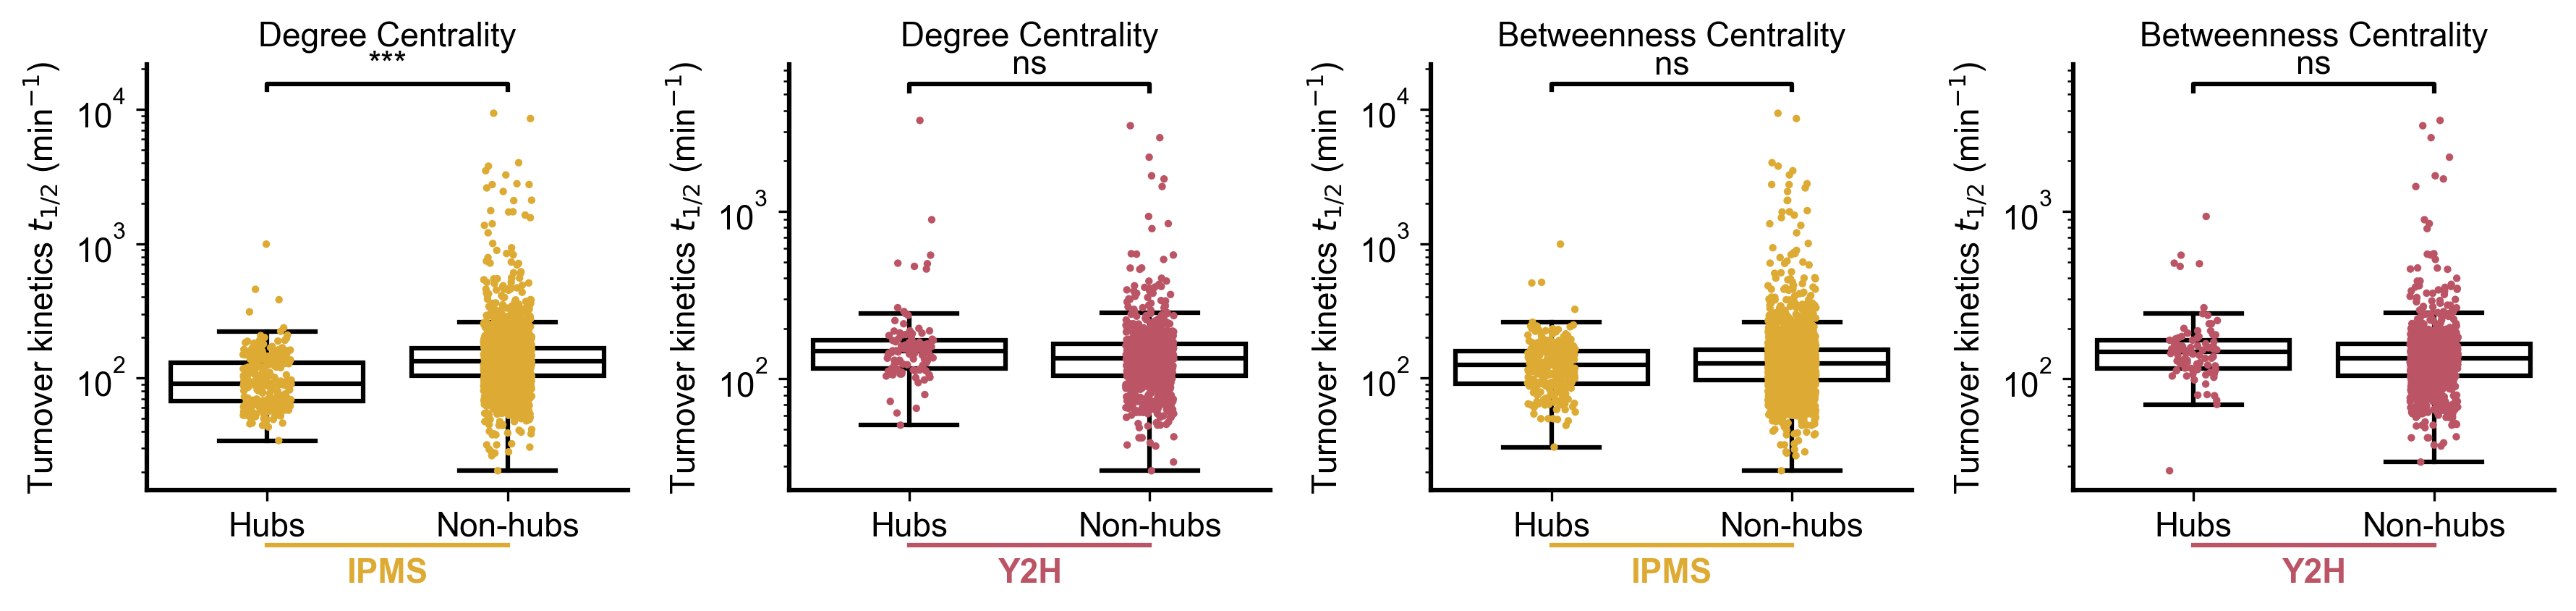

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import os

# Set global font settings for publication quality
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300

def test_hub_halflife_boxplot_single(selected_columns, col, network_name, color, save_dir, metric_name, ax=None, save=True, show=True, print_stats=True):
    # === Define hub vs non-hub groups ===
    hubs = selected_columns[selected_columns[col] >= 90]['Villen_halflife_min'].dropna()
    nonhubs = selected_columns[selected_columns[col] < 90]['Villen_halflife_min'].dropna()
    
    # === Combine into a single dataframe ===
    data = pd.DataFrame({
        'Group': (['Hubs'] * len(hubs)) + (['Non-hubs'] * len(nonhubs)),
        't_half': np.concatenate([hubs, nonhubs])
    })
    
    # === Mann–Whitney tests (on log-transformed data for statistical test) ===
    def log_transform(series):
        return np.log10(series + 1)  # Add 1 to avoid log(0)
    
    log_hubs = log_transform(hubs)
    log_nonhubs = log_transform(nonhubs)
    
    if print_stats:
        print(f"\n=== Percentage Differences for {network_name} {metric_name} ===")
        hubs_median = np.median(hubs)
        nonhubs_median = np.median(nonhubs)
        percentage = ((hubs_median - nonhubs_median) / nonhubs_median) * 100 if nonhubs_median != 0 else 0
        print(f"Hubs {network_name} are {percentage:.2f}% greater than Non-hubs {network_name} (medians: {hubs_median:.2f} vs {nonhubs_median:.2f})")

        print(f"\n=== Mann–Whitney U Tests (log-transformed) for {network_name} {metric_name} ===")
        stat, p = mannwhitneyu(log_hubs, log_nonhubs, alternative='two-sided')
        print(f"{network_name} Hubs vs Non-hubs: U={stat:.2f}, p={p:.4g}, n1={len(hubs)}, n2={len(nonhubs)}")

        print(f"\n=== Kolmogorov-Smirnov Tests (log-transformed) for {network_name} {metric_name} ===")
        ks_stat, ks_p = ks_2samp(log_hubs, log_nonhubs)
        print(f"{network_name} Hubs vs Non-hubs: KS={ks_stat:.2f}, p={ks_p:.4g}, n1={len(hubs)}, n2={len(nonhubs)}")
    else:
        # Still compute p_value even if not printing
        _, p = mannwhitneyu(log_hubs, log_nonhubs, alternative='two-sided')
    
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
    
    # === Plot: swarm overlay + Boxplot ===
    sns.stripplot(
        data=data,
        x='Group',
        y='t_half',  # Use original Villen_halflife_min data
        palette={'Hubs': color, 'Non-hubs': color},
        size=2.5,
        alpha=1.0,
        jitter=True,
        ax=ax
    )
    sns.boxplot(
        data=data,
        x='Group',
        y='t_half',  # Use original Villen_halflife_min data
        palette={'Hubs': color, 'Non-hubs': color},
        showcaps=True,
        showfliers=False,
        fliersize=2,
        linewidth=1.5,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5},
        width=0.8,
        ax=ax
    )
    for i, artist in enumerate(ax.patches):
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    
    # === Set y-axis to logarithmic scale ===
    ax.set_yscale('log')
    ax.set_ylabel(r'Turnover kinetics $t_{1/2}$ (min$^{-1}$)')
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Hubs', 'Non-hubs'], rotation=0, ha='center')
    
    # === Add significance bars ===
    def add_significance_bar(x1, x2, y, p_value, ax, force_ns=False):
        height = y
        ax.plot([x1, x1, x2, x2], [height, height * 1.1, height * 1.1, height], lw=1.5, c='black')
        stars = 'ns' if force_ns or p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, height * 1.15, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11)
    
    max_y = data['t_half'].max()
    y_start = max_y * 1.5
    force_ns = (network_name == 'Y2H')
    add_significance_bar(0, 1, y_start, p, ax, force_ns=force_ns)
    
    # Add horizontal line under the pair
    ax.plot([0, 1], [-0.13, -0.13], color=color, lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.16, network_name, ha='center', va='top', fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(), color=color, fontweight='bold')
    
    ax.set_title(f'{metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        figure_label = '5A' if 'Degree' in metric_name else '5A'
        # Use global counter for numbering
        if not hasattr(test_hub_halflife_boxplot_single, "counter"):
            test_hub_halflife_boxplot_single.counter = 1
        save_path = os.path.join(save_dir, f"{figure_label}.{test_hub_halflife_boxplot_single.counter}.svg")
        test_hub_halflife_boxplot_single.counter += 1

        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
    
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())

# === Example: loop over all four combinations ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE5"
combinations = [
    ('MS_degree_centrality_percentile', 'IPMS', '#DDAA33', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', '#BB5566', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', '#DDAA33', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', '#BB5566', 'Betweenness Centrality')
]

# Save individual plots (with stats printed)
for col, network_name, color, metric_name in combinations:
    test_hub_halflife_boxplot_single(filtered_df, col, network_name, color, save_dir, metric_name, ax=None, save=True, show=False, print_stats=True)

# Display adjacent plots in 2x2 grid (no additional prints)
fig, axs = plt.subplots(1, 4, figsize=(12, 3))  # Adjust figsize as needed
for i, (col, network_name, color, metric_name) in enumerate(combinations):
    test_hub_halflife_boxplot_single(
        filtered_df, col, network_name, color, save_dir, metric_name,
        ax=axs[i], save=False, show=False, print_stats=False
    )
plt.tight_layout()
plt.show()


=== Counts for IPMS Degree Centrality Hubs ===
Hubs IPMS: static=175, dynamic=151

=== Percentage Differences for IPMS Degree Centrality Hubs ===
Static Hubs IPMS are 17.33% greater than Dynamic Hubs IPMS (medians: 105.60 vs 90.00)

=== Mann-Whitney U Test (log-transformed) for IPMS Degree Centrality Hubs ===
Hubs: U=16817.50, p=2.155e-05

=== Kolmogorov-Smirnov Tests (log-transformed) for IPMS Degree Centrality Hubs ===
Hubs: KS=0.33, p=1.828e-08

=== Counts for IPMS Degree Centrality Non-hubs ===
Non-hubs IPMS: static=908, dynamic=1054

=== Percentage Differences for IPMS Degree Centrality Non-hubs ===
Static Non-hubs IPMS are -5.46% greater than Dynamic Non-hubs IPMS (medians: 129.90 vs 137.40)

=== Mann-Whitney U Test (log-transformed) for IPMS Degree Centrality Non-hubs ===
Non-hubs: U=445861.50, p=0.009059

=== Kolmogorov-Smirnov Tests (log-transformed) for IPMS Degree Centrality Non-hubs ===
Non-hubs: KS=0.13, p=1.856e-07


/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['complex_type'] = np.where(data['in_complex'].astype(bool), 'Static', 'Dynamic')
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o


=== Counts for Y2H Degree Centrality Hubs ===
Hubs Y2H: static=55, dynamic=53

=== Percentage Differences for Y2H Degree Centrality Hubs ===
Static Hubs Y2H are -5.86% greater than Dynamic Hubs Y2H (medians: 144.60 vs 153.60)

=== Mann-Whitney U Test (log-transformed) for Y2H Degree Centrality Hubs ===
Hubs: U=1347.50, p=0.501

=== Kolmogorov-Smirnov Tests (log-transformed) for Y2H Degree Centrality Hubs ===
Hubs: KS=0.22, p=0.1347

=== Counts for Y2H Degree Centrality Non-hubs ===
Non-hubs Y2H: static=1028, dynamic=1152

=== Percentage Differences for Y2H Degree Centrality Non-hubs ===
Static Non-hubs Y2H are -2.10% greater than Dynamic Non-hubs Y2H (medians: 126.00 vs 128.70)

=== Mann-Whitney U Test (log-transformed) for Y2H Degree Centrality Non-hubs ===
Non-hubs: U=575588.50, p=0.2596

=== Kolmogorov-Smirnov Tests (log-transformed) for Y2H Degree Centrality Non-hubs ===
Non-hubs: KS=0.11, p=2.3e-06


/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['complex_type'] = np.where(data['in_complex'].astype(bool), 'Static', 'Dynamic')
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o


=== Counts for IPMS Betweenness Centrality Hubs ===
Hubs IPMS: static=163, dynamic=123

=== Percentage Differences for IPMS Betweenness Centrality Hubs ===
Static Hubs IPMS are 11.98% greater than Dynamic Hubs IPMS (medians: 129.00 vs 115.20)

=== Mann-Whitney U Test (log-transformed) for IPMS Betweenness Centrality Hubs ===
Hubs: U=10380.50, p=0.6077

=== Kolmogorov-Smirnov Tests (log-transformed) for IPMS Betweenness Centrality Hubs ===
Hubs: KS=0.18, p=0.01884

=== Counts for IPMS Betweenness Centrality Non-hubs ===
Non-hubs IPMS: static=920, dynamic=1082

=== Percentage Differences for IPMS Betweenness Centrality Non-hubs ===
Static Non-hubs IPMS are -3.21% greater than Dynamic Non-hubs IPMS (medians: 126.60 vs 130.80)

=== Mann-Whitney U Test (log-transformed) for IPMS Betweenness Centrality Non-hubs ===
Non-hubs: U=480605.00, p=0.1843

=== Kolmogorov-Smirnov Tests (log-transformed) for IPMS Betweenness Centrality Non-hubs ===
Non-hubs: KS=0.11, p=1.05e-05


/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['complex_type'] = np.where(data['in_complex'].astype(bool), 'Static', 'Dynamic')
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o


=== Counts for Y2H Betweenness Centrality Hubs ===
Hubs Y2H: static=55, dynamic=37

=== Percentage Differences for Y2H Betweenness Centrality Hubs ===
Static Hubs Y2H are -7.81% greater than Dynamic Hubs Y2H (medians: 141.60 vs 153.60)

=== Mann-Whitney U Test (log-transformed) for Y2H Betweenness Centrality Hubs ===
Hubs: U=860.00, p=0.2112

=== Kolmogorov-Smirnov Tests (log-transformed) for Y2H Betweenness Centrality Hubs ===
Hubs: KS=0.29, p=0.03856

=== Counts for Y2H Betweenness Centrality Non-hubs ===
Non-hubs Y2H: static=1028, dynamic=1168

=== Percentage Differences for Y2H Betweenness Centrality Non-hubs ===
Static Non-hubs Y2H are -2.09% greater than Dynamic Non-hubs Y2H (medians: 126.30 vs 129.00)

=== Mann-Whitney U Test (log-transformed) for Y2H Betweenness Centrality Non-hubs ===
Non-hubs: U=584073.50, p=0.2722

=== Kolmogorov-Smirnov Tests (log-transformed) for Y2H Betweenness Centrality Non-hubs ===
Non-hubs: KS=0.11, p=2.783e-06


/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['complex_type'] = np.where(data['in_complex'].astype(bool), 'Static', 'Dynamic')
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_837311/2386324174.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

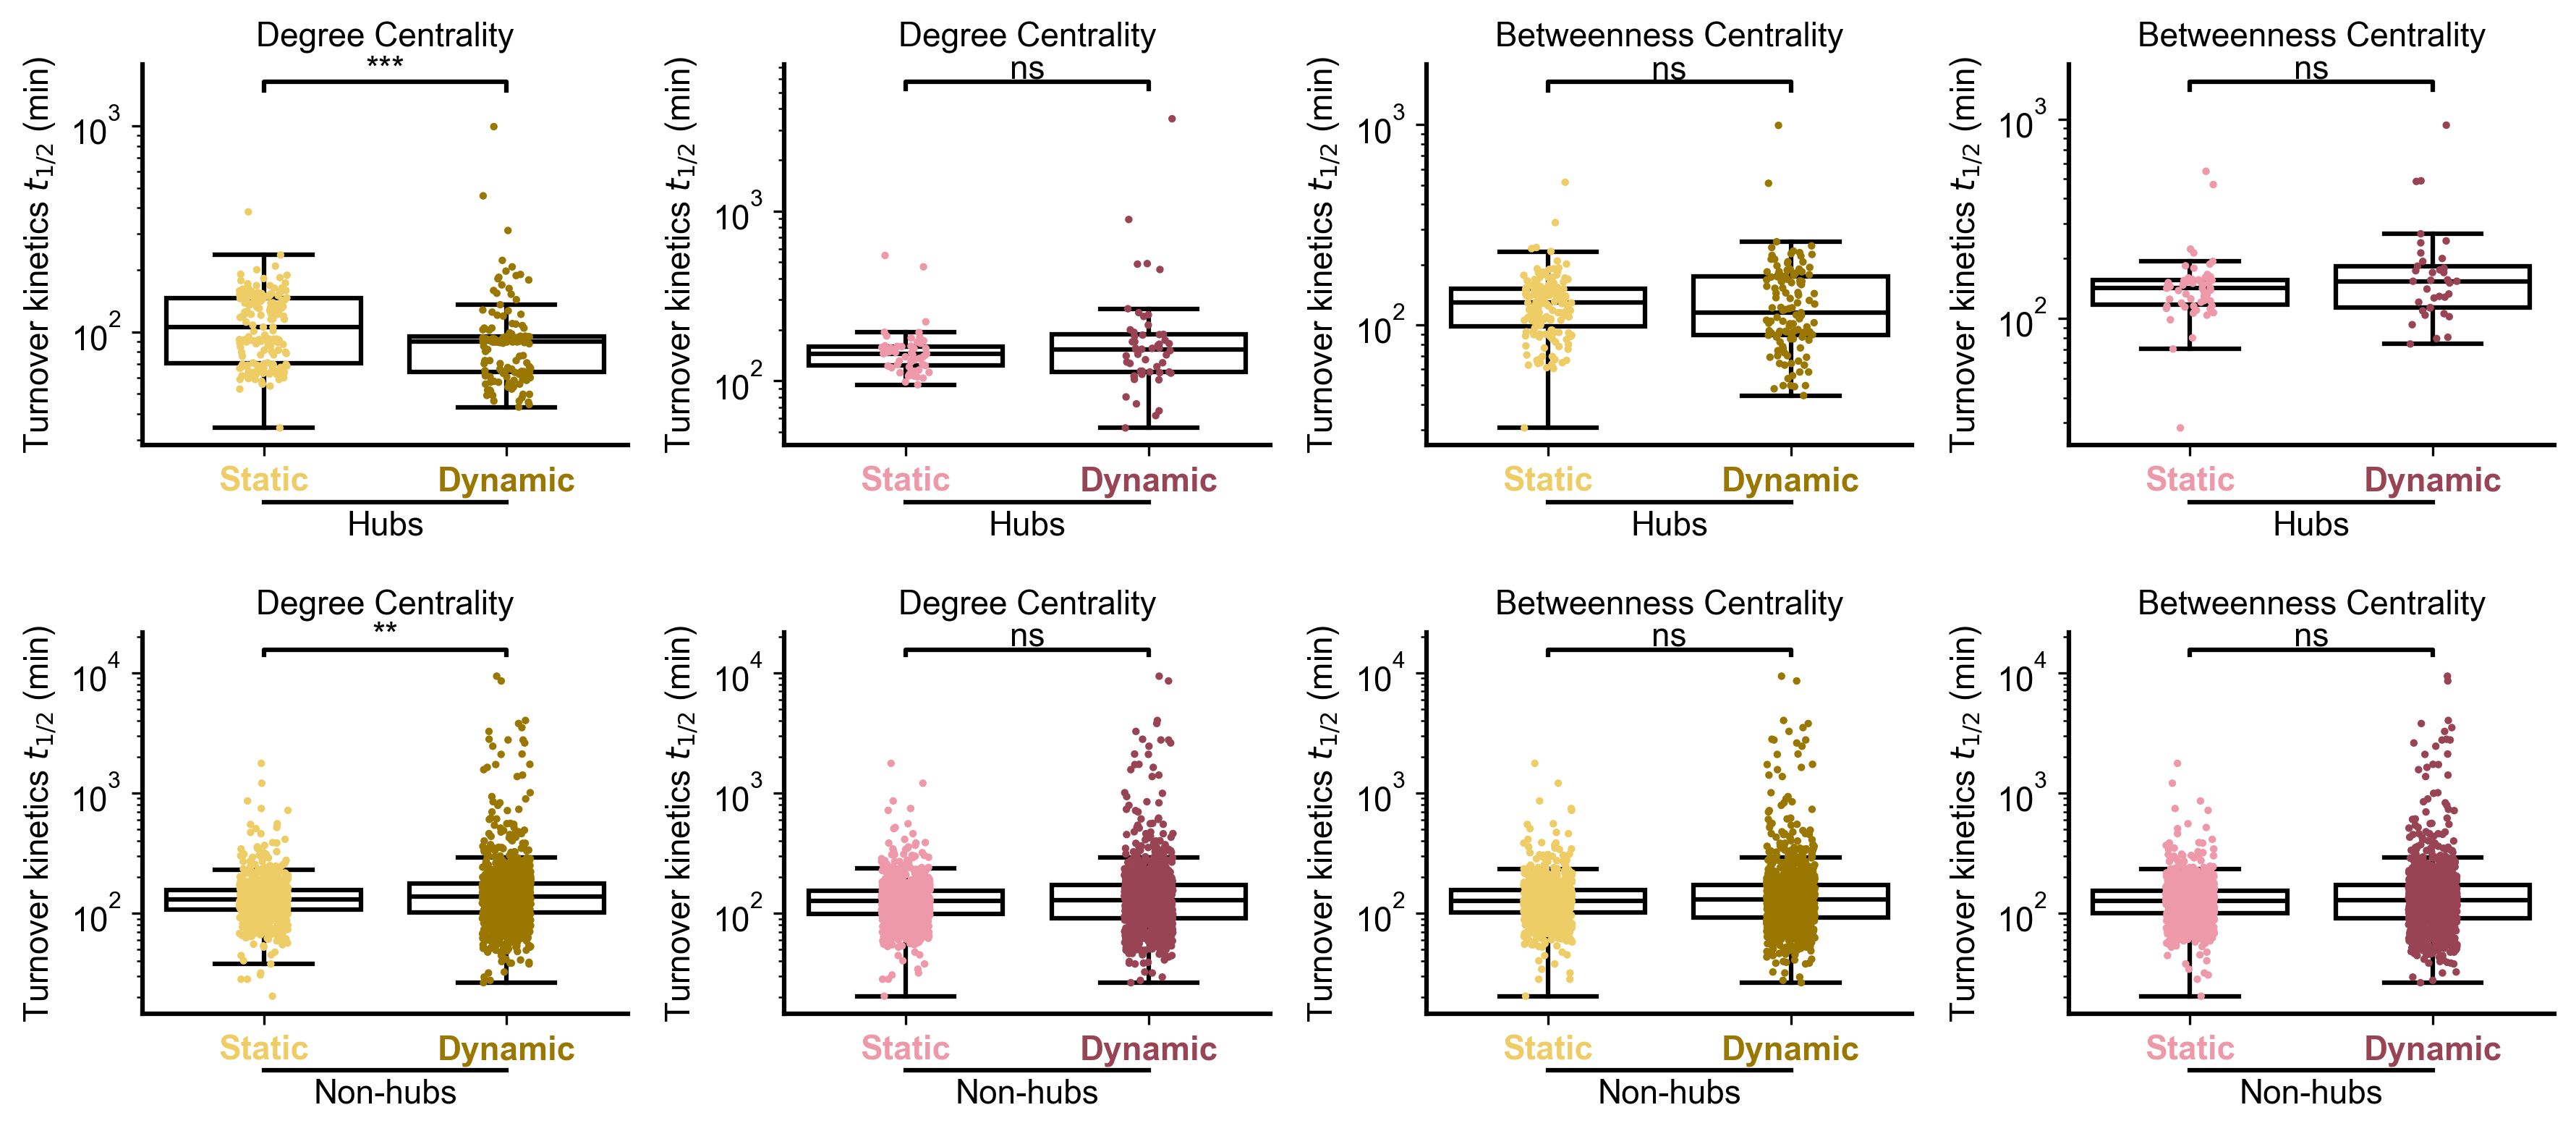

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import os
from matplotlib.patches import Patch
import warnings
# ===== Global matplotlib settings =====
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
# ===== Function to plot single hub complex boxplot =====
def test_hub_complex_boxplot_single(selected_columns, col, network_name, save_dir, metric_name, plot_hub_type, ax=None, save=True, show=True, print_stats=True):
    warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")
    # === Define hub status ===
    hub_status = selected_columns[col] >= 90
    # === Compute stats ===
    hub_df = selected_columns[hub_status]
    static_hub = hub_df[hub_df['in_complex'].astype(bool)]['Villen_halflife_min'].dropna()
    dynamic_hub = hub_df[~hub_df['in_complex'].astype(bool)]['Villen_halflife_min'].dropna()
    non_hub_df = selected_columns[~hub_status]
    static_non = non_hub_df[non_hub_df['in_complex'].astype(bool)]['Villen_halflife_min'].dropna()
    dynamic_non = non_hub_df[~non_hub_df['in_complex'].astype(bool)]['Villen_halflife_min'].dropna()
    def log_transform(series):
        return np.log10(series + 1) # Add 1 to avoid log(0)
    log_static_hub = log_transform(static_hub)
    log_dynamic_hub = log_transform(dynamic_hub)
    stat_h, p_h = (mannwhitneyu(log_static_hub, log_dynamic_hub, alternative='two-sided') if len(static_hub) > 0 and len(dynamic_hub) > 0 else (np.nan, 1.0))
    log_static_non = log_transform(static_non)
    log_dynamic_non = log_transform(dynamic_non)
    stat_n, p_n = (mannwhitneyu(log_static_non, log_dynamic_non, alternative='two-sided') if len(static_non) > 0 and len(dynamic_non) > 0 else (np.nan, 1.0))
    ks_stat_h, ks_p_h = (ks_2samp(log_static_hub, log_dynamic_hub) if len(static_hub) > 0 and len(dynamic_hub) > 0 else (np.nan, 1.0))
    ks_stat_n, ks_p_n = (ks_2samp(log_static_non, log_dynamic_non) if len(static_non) > 0 and len(dynamic_non) > 0 else (np.nan, 1.0))
    if print_stats:
        print(f"\n=== Counts for {network_name} {metric_name} {plot_hub_type} ===")
        if plot_hub_type == 'Hubs':
            print(f"{plot_hub_type} {network_name}: static={len(static_hub)}, dynamic={len(dynamic_hub)}")
        else:
            print(f"{plot_hub_type} {network_name}: static={len(static_non)}, dynamic={len(dynamic_non)}")
        print(f"\n=== Percentage Differences for {network_name} {metric_name} {plot_hub_type} ===")
        if plot_hub_type == 'Hubs':
            static_median = np.median(static_hub)
            dynamic_median = np.median(dynamic_hub)
            percentage = ((static_median - dynamic_median) / dynamic_median) * 100 if dynamic_median != 0 else 0
            print(f"Static {plot_hub_type} {network_name} are {percentage:.2f}% greater than Dynamic {plot_hub_type} {network_name} (medians: {static_median:.2f} vs {dynamic_median:.2f})")
        else:
            static_median = np.median(static_non)
            dynamic_median = np.median(dynamic_non)
            percentage = ((static_median - dynamic_median) / dynamic_median) * 100 if dynamic_median != 0 else 0
            print(f"Static {plot_hub_type} {network_name} are {percentage:.2f}% greater than Dynamic {plot_hub_type} {network_name} (medians: {static_median:.2f} vs {dynamic_median:.2f})")
        print(f"\n=== Mann-Whitney U Test (log-transformed) for {network_name} {metric_name} {plot_hub_type} ===")
        if plot_hub_type == 'Hubs':
            print(f"{plot_hub_type}: U={stat_h:.2f}, p={p_h:.4g}")
        else:
            print(f"{plot_hub_type}: U={stat_n:.2f}, p={p_n:.4g}")
        print(f"\n=== Kolmogorov-Smirnov Tests (log-transformed) for {network_name} {metric_name} {plot_hub_type} ===")
        if plot_hub_type == 'Hubs':
            print(f"{plot_hub_type}: KS={ks_stat_h:.2f}, p={ks_p_h:.4g}")
        else:
            print(f"{plot_hub_type}: KS={ks_stat_n:.2f}, p={ks_p_n:.4g}")
    # === Filter data based on plot_hub_type ===
    if plot_hub_type == 'Hubs':
        data = hub_df
        p = p_h
    elif plot_hub_type == 'Non-hubs':
        data = non_hub_df
        p = p_n
    else:
        raise ValueError("plot_hub_type must be 'Hubs' or 'Non-hubs'")
    data['complex_type'] = np.where(data['in_complex'].astype(bool), 'Static', 'Dynamic')
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
    # === Set color scheme ===
    if network_name == 'Y2H':
        palette = {'Static': '#EE99AA', 'Dynamic': '#994455'}
        bottom_color = 'black'
    else: # IPMS
        palette = {'Static': '#EECC66', 'Dynamic': '#997700'}
        bottom_color = 'black'
    # === Plot: swarm overlay + Boxplot ===
    sns.stripplot(
        data=data,
        x='complex_type',
        y='Villen_halflife_min',
        hue='complex_type',
        order=['Static', 'Dynamic'],
        hue_order=['Static', 'Dynamic'],
        palette=palette,
        size=2.5,
        alpha=1.0,
        jitter=True,
        dodge=False,
        ax=ax
    )
    sns.boxplot(
        data=data,
        x='complex_type',
        y='Villen_halflife_min',
        hue='complex_type',
        order=['Static', 'Dynamic'],
        hue_order=['Static', 'Dynamic'],
        palette=palette,
        ax=ax,
        width=0.8,
        fliersize=2,
        linewidth=1.5,
        showcaps=True,
        showfliers=False,
        dodge=False,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5}
    )
    for artist in ax.patches:
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_yscale('log')
    ax.set_ylabel(r'Turnover kinetics $t_{1/2}$ (min)')
    ax.set_xlabel('')
    ax.set_xticklabels(['Static', 'Dynamic'], rotation=0, ha='center')
    ax.set_xticks([0, 1])
    
    # Color and bold the x-tick labels
    labels = ax.get_xticklabels()
    labels[0].set_color(palette['Static'])
    labels[1].set_color(palette['Dynamic'])
    for label in labels:
        label.set_fontweight('bold')
    # === Add significance bars ===
    def add_significance_bar(x1, x2, y, p_value, ax):
        height = y
        ax.plot([x1, x1, x2, x2], [height, height * 1.1, height * 1.1, height], lw=1.5, c='black')
        stars = 'ns' if p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, height * 1.05, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11)
    max_y = data['Villen_halflife_min'].max()
    y_start = max_y * 1.5
    add_significance_bar(0, 1, y_start, p, ax)
    # === Bottom line + hub type ===
    ax.plot([0, 1], [-0.15, -0.15], color=bottom_color, lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.17, plot_hub_type, ha='center', va='top',
            fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(),
            color=bottom_color)
    ax.set_title(f'{metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)

        # Use label 5C for these plots
        figure_label = "5C"

        # Initialize persistent counter if it doesn't exist
        if not hasattr(test_hub_complex_boxplot_single, "counter"):
            test_hub_complex_boxplot_single.counter = 1

        # New filename format: 5C.1, 5C.2, ...
        save_path = os.path.join(save_dir, f"{figure_label}.{test_hub_complex_boxplot_single.counter}.svg")

        # Increment counter for next plot
        test_hub_complex_boxplot_single.counter += 1

        # Save the figure
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')

    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())

    
# ===== Example: loop over all four combinations =====
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE5"
combinations = [
    ('MS_degree_centrality_percentile', 'IPMS', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', 'Betweenness Centrality')
]
# Save individual plots (with stats printed)
for col, network_name, metric_name in combinations:
    test_hub_complex_boxplot_single(filtered_df, col, network_name, save_dir, metric_name, plot_hub_type='Hubs', ax=None, save=True, show=False, print_stats=True)
    test_hub_complex_boxplot_single(filtered_df, col, network_name, save_dir, metric_name, plot_hub_type='Non-hubs', ax=None, save=True, show=False, print_stats=True)
# Display adjacent plots in 2x4 grid
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
i = 0
for col, network_name, metric_name in combinations:
    test_hub_complex_boxplot_single(filtered_df, col, network_name, save_dir, metric_name, plot_hub_type='Hubs', ax=axs[0, i], save=False, show=False, print_stats=False)
    test_hub_complex_boxplot_single(filtered_df, col, network_name, save_dir, metric_name, plot_hub_type='Non-hubs', ax=axs[1, i], save=False, show=False, print_stats=False)
    i += 1
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


=== Spearman Correlations for IPMS Degree Centrality - Ghosh-Dill ΔG ===
Overall: rho=0.0174, p=0.4068, n=2287
Hubs: rho=0.2052, p=0.0001906, n=326

=== Pearson Correlations (on log(t1/2)) for IPMS Degree Centrality - Ghosh-Dill ΔG ===
Overall: r=-0.0022, p=0.9146, n=2287
Hubs: r=0.1217, p=0.02798, n=326

=== Spearman Correlations for Y2H Degree Centrality - Ghosh-Dill ΔG ===
Overall: rho=-0.0685, p=0.03494, n=949
Hubs: rho=0.0166, p=0.8648, n=108

=== Pearson Correlations (on log(t1/2)) for Y2H Degree Centrality - Ghosh-Dill ΔG ===
Overall: r=-0.0832, p=0.01039, n=949
Hubs: r=0.0157, p=0.8716, n=108

=== Spearman Correlations for IPMS Betweenness Centrality - Ghosh-Dill ΔG ===
Overall: rho=0.0174, p=0.4068, n=2287
Hubs: rho=0.1357, p=0.02166, n=286

=== Pearson Correlations (on log(t1/2)) for IPMS Betweenness Centrality - Ghosh-Dill ΔG ===
Overall: r=-0.0022, p=0.9146, n=2287
Hubs: r=0.1071, p=0.07052, n=286

=== Spearman Correlations for Y2H Betweenness Centrality - Ghosh-Dill ΔG ==

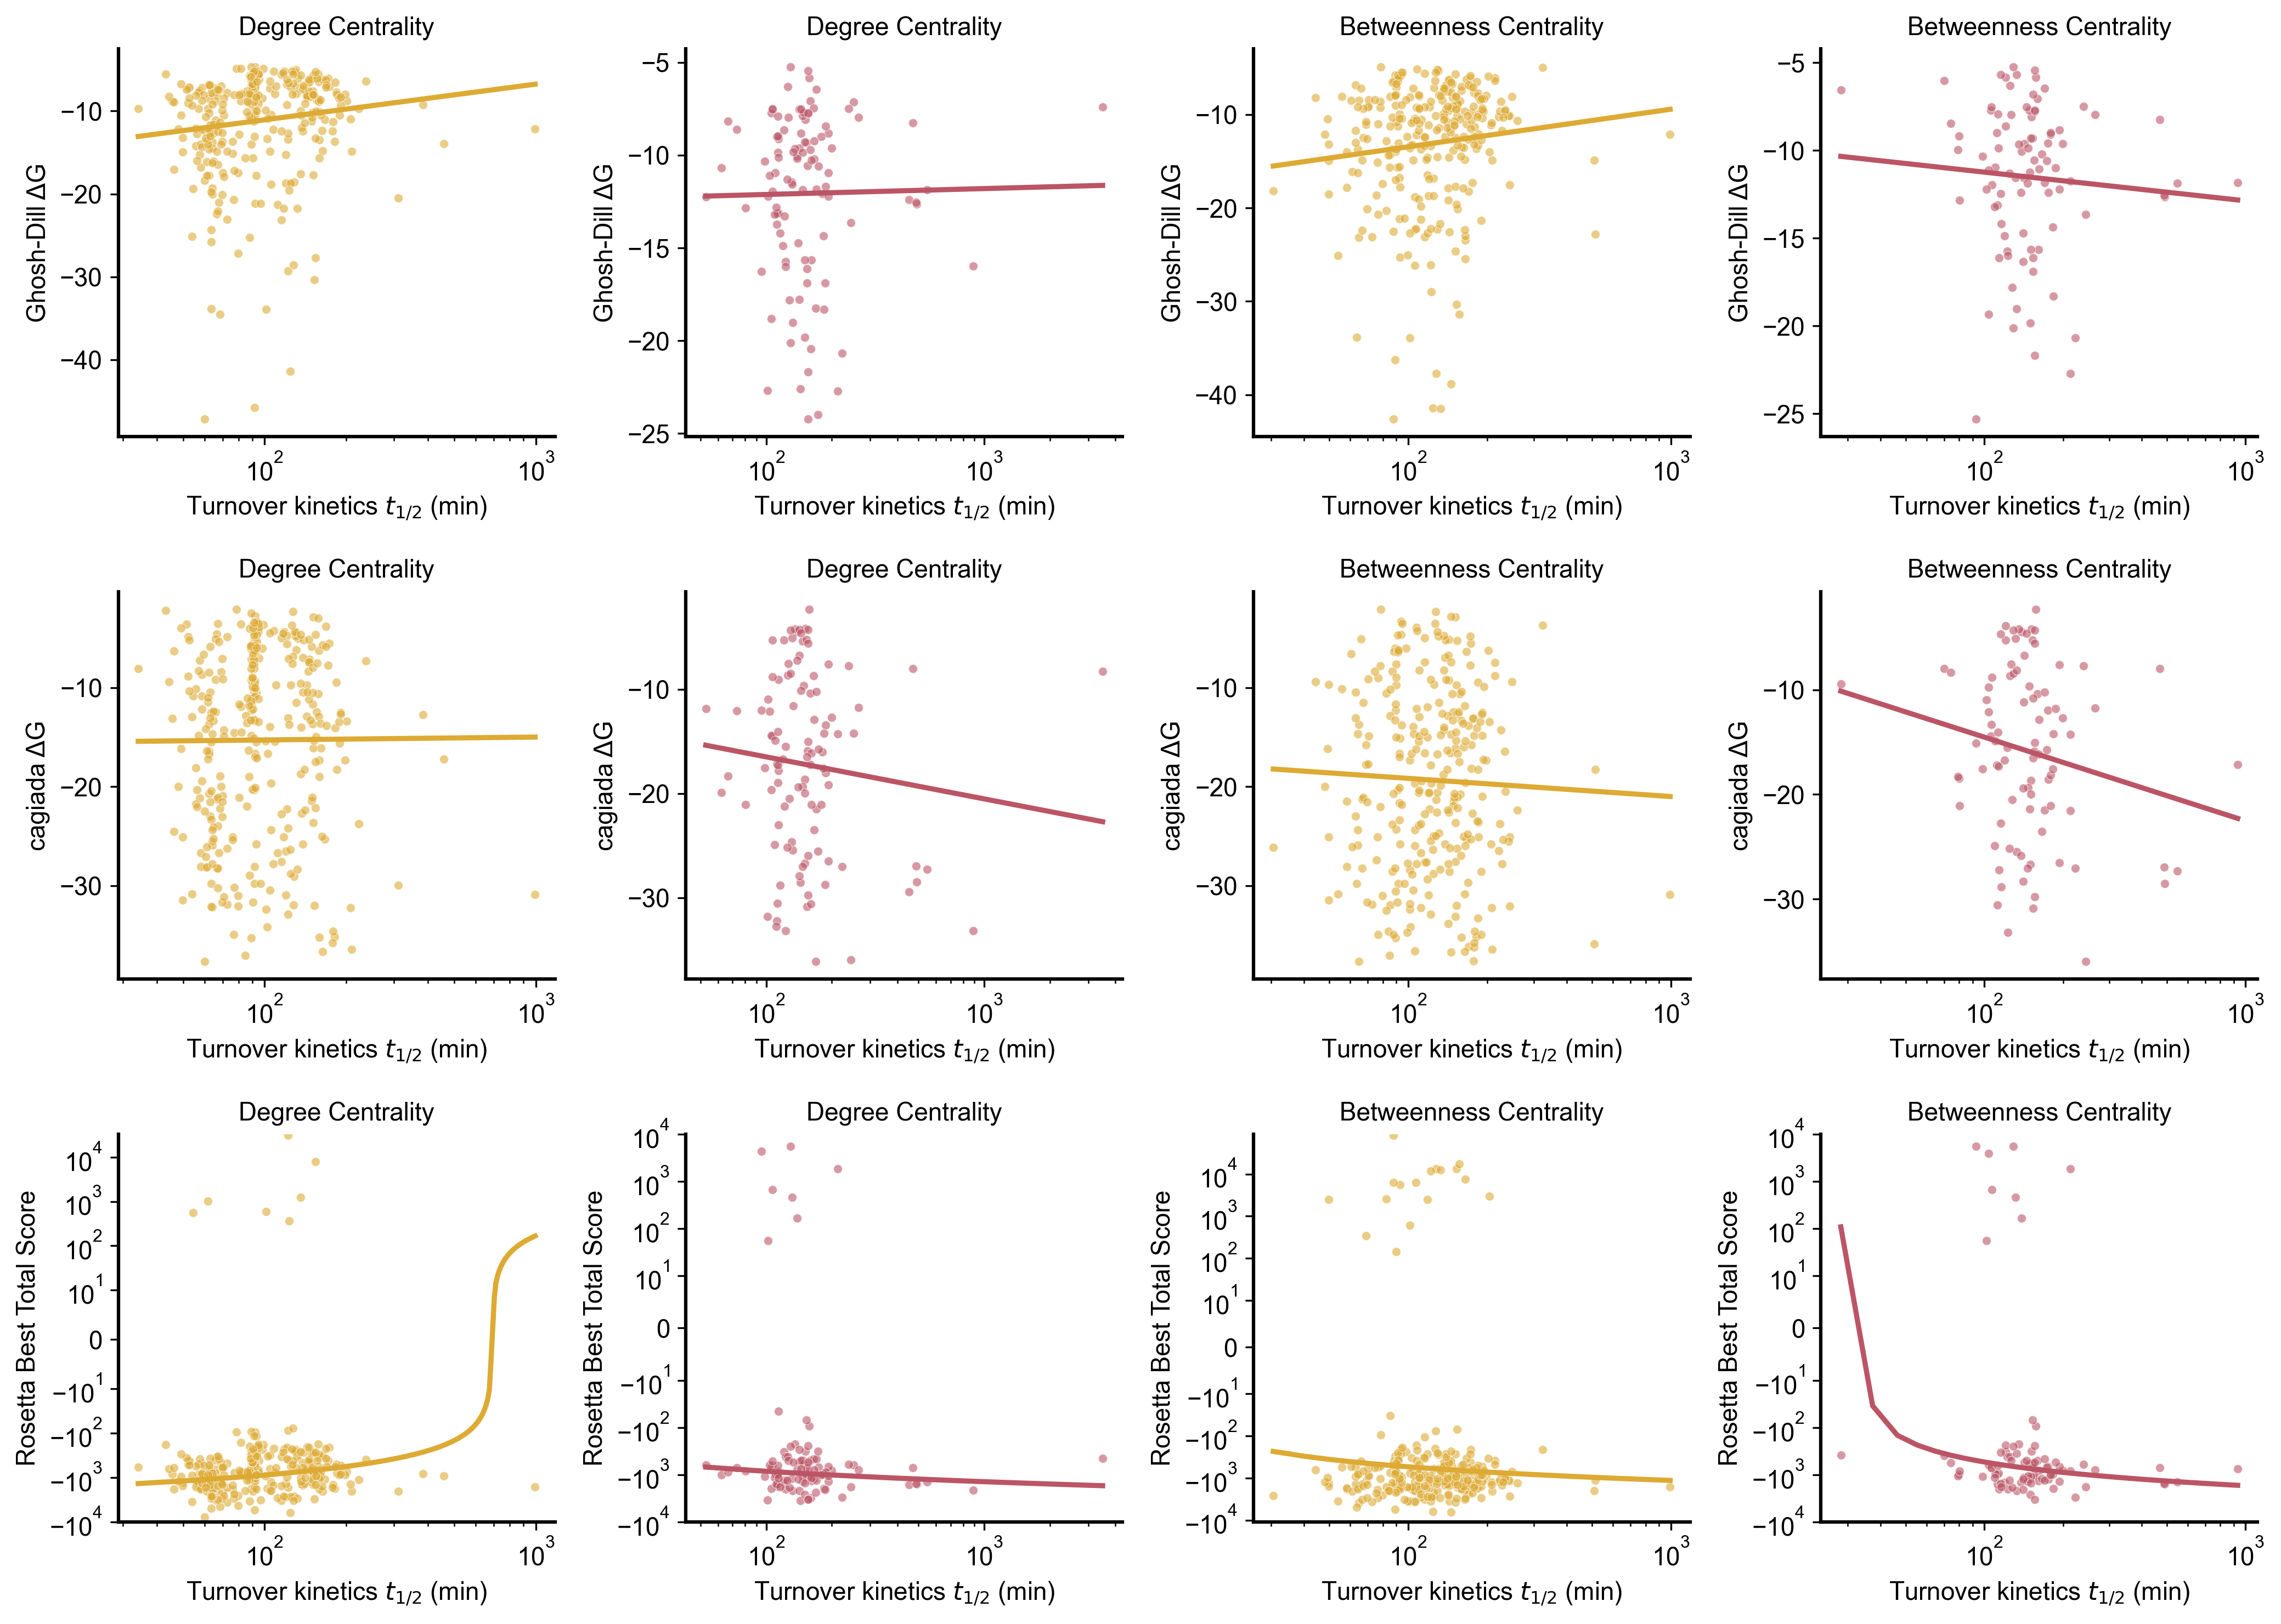

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import os
import matplotlib.ticker as ticker
# Set global font settings for publication quality
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.ioff()
def test_hub_stability_correlation_single(selected_columns, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=True, print_stats=True):
    # === Prepare data ===
    data = selected_columns[[col, 'Villen_halflife_min', stability_col]].dropna()
 
    # === Filter to only hubs ===
    hubs_data = data[data[col] >= 90]
 
    # === Compute Spearman correlations ===
    if print_stats:
        print(f"\n=== Spearman Correlations for {network_name} {metric_name} - {stability_name} ===")
        # Overall
        rho_all, p_all = spearmanr(data['Villen_halflife_min'], data[stability_col])
        print(f"Overall: rho={rho_all:.4f}, p={p_all:.4g}, n={len(data)}")
        # Hubs
        if len(hubs_data) > 1:
            rho_hubs, p_hubs = spearmanr(hubs_data['Villen_halflife_min'], hubs_data[stability_col])
            print(f"Hubs: rho={rho_hubs:.4f}, p={p_hubs:.4g}, n={len(hubs_data)}")
        else:
            print("Hubs: Insufficient data for correlation")
      
        print(f"\n=== Pearson Correlations (on log(t1/2)) for {network_name} {metric_name} - {stability_name} ===")
        # Overall
        log_x_all = np.log10(data['Villen_halflife_min'])
        r_all, p_all = pearsonr(log_x_all, data[stability_col])
        print(f"Overall: r={r_all:.4f}, p={p_all:.4g}, n={len(data)}")
        # Hubs
        if len(hubs_data) > 1:
            log_x_hubs = np.log10(hubs_data['Villen_halflife_min'])
            r_hubs, p_hubs = pearsonr(log_x_hubs, hubs_data[stability_col])
            print(f"Hubs: r={r_hubs:.4f}, p={p_hubs:.4g}, n={len(hubs_data)}")
        else:
            print("Hubs: Insufficient data for correlation")
 
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
 
    # === Plot: scatter plot (only hubs) ===
    sns.scatterplot(
        data=hubs_data,
        x='Villen_halflife_min',
        y=stability_col,
        color=color,
        alpha=0.6,
        s=15,
        ax=ax
    )
 
    # === Add trend line (linear regression with logx) for hubs ===
    if len(hubs_data) > 1:
        sns.regplot(
            data=hubs_data,
            x='Villen_halflife_min',
            y=stability_col,
            scatter=False,
            color=color,
            logx=True,
            ci=None,
            ax=ax
        )
 
    # === Set scales and labels ===
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(ticker.LogLocator(subs=[1.0]))
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.set_xlabel(r'Turnover kinetics $t_{1/2}$ (min)')
    ax.set_ylabel(stability_name)
 
    # Set y-scale to symlog for Rosetta
    if 'Rosetta' in stability_name:
        ax.set_yscale('symlog', linthresh=10)
        ax.set_yticks([-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000])
 
    # === No legend ===
 
    ax.set_title(f'{metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
 
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        # Always use label 5C
        figure_label = '5B'
        # Persistent counter (across multiple calls)
        if not hasattr(test_hub_stability_correlation_single, "counter"):
            test_hub_stability_correlation_single.counter = 1
        # New filename format
        save_path = os.path.join(save_dir, f"{figure_label}.{test_hub_stability_correlation_single.counter}.svg")
        # Increment for next plot
        test_hub_stability_correlation_single.counter += 1
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
 
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())
# === Example: loop over all four combinations and three stability metrics ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE5"
combinations = [
    ('MS_degree_centrality_percentile', 'IPMS', '#DDAA33', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', '#BB5566', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', '#DDAA33', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', '#BB5566', 'Betweenness Centrality')
]
stability_metrics = [
    ('Ghosh-Dill-dG', 'Ghosh-Dill ΔG'),
    ('cagiada-dG', 'cagiada ΔG'),
    ('Rosetta_best_total_score', 'Rosetta Best Total Score')
]
# Save individual plots (with stats printed)
for stability_col, stability_name in stability_metrics:
    for col, network_name, color, metric_name in combinations:
        test_hub_stability_correlation_single(filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=False, print_stats=True)
# Optional: Display in a 3x4 grid (one row per stability metric, no additional prints)
fig, axs = plt.subplots(3, 4, figsize=(14, 10)) # 3 stability x 4 combinations
for i, (stability_col, stability_name) in enumerate(stability_metrics):
    for j, (col, network_name, color, metric_name) in enumerate(combinations):
         test_hub_stability_correlation_single(
             filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name,
             ax=axs[i, j], save=False, show=False, print_stats=False
         )
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


=== Spearman Correlations for IPMS Degree Centrality - Meltome Melting Point (°C) ===
Overall: rho=0.2144, p=5.65e-16, n=1396
Hubs: rho=0.1562, p=0.01522, n=241

=== Pearson Correlations (on log(t1/2)) for IPMS Degree Centrality - Meltome Melting Point (°C) ===
Overall: r=0.1592, p=2.228e-09, n=1396
Hubs: r=0.2044, p=0.00142, n=241

=== Spearman Correlations for Y2H Degree Centrality - Meltome Melting Point (°C) ===
Overall: rho=0.1268, p=0.001994, n=592
Hubs: rho=0.0152, p=0.9005, n=70

=== Pearson Correlations (on log(t1/2)) for Y2H Degree Centrality - Meltome Melting Point (°C) ===
Overall: r=0.0543, p=0.1872, n=592
Hubs: r=-0.1393, p=0.2501, n=70

=== Spearman Correlations for IPMS Betweenness Centrality - Meltome Melting Point (°C) ===
Overall: rho=0.2144, p=5.65e-16, n=1396
Hubs: rho=0.3545, p=6.056e-08, n=221

=== Pearson Correlations (on log(t1/2)) for IPMS Betweenness Centrality - Meltome Melting Point (°C) ===
Overall: r=0.1592, p=2.228e-09, n=1396
Hubs: r=0.3084, p=2.971e-0

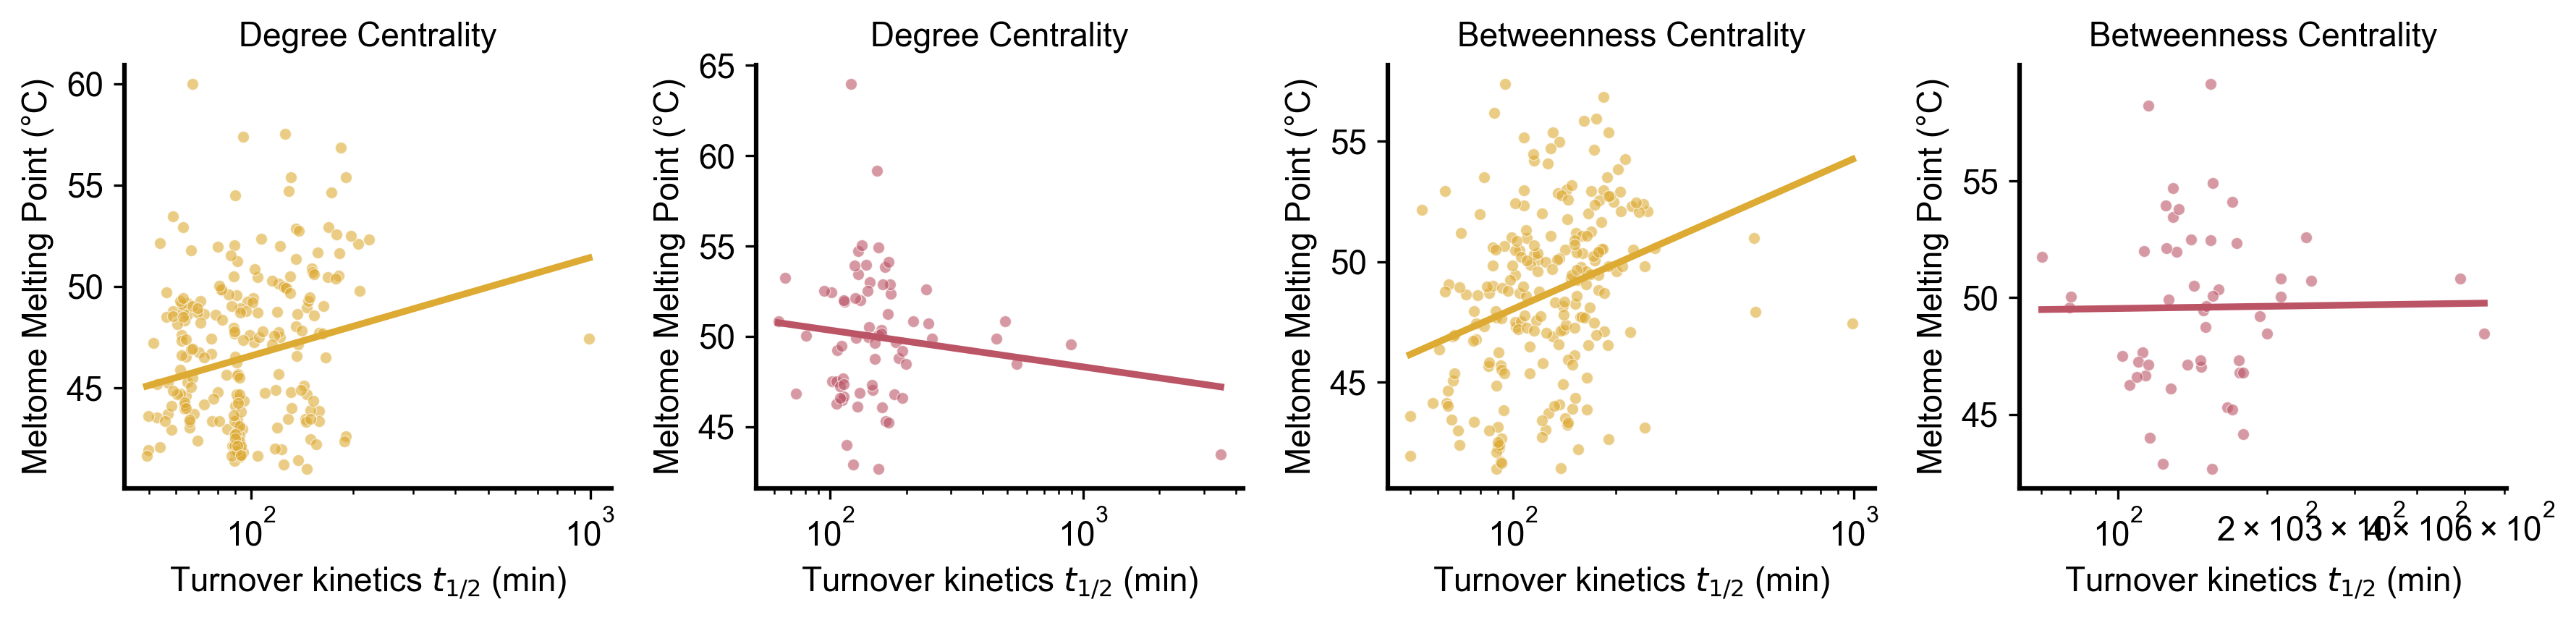

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import os
import matplotlib.ticker as ticker
# Set global font settings for publication quality
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
plt.ioff()
def test_hub_stability_correlation_single(selected_columns, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=True, print_stats=True):
    # === Prepare data ===
    data = selected_columns[[col, 'Villen_halflife_min', stability_col]].dropna()
 
    # === Filter to only hubs ===
    hubs_data = data[data[col] >= 90]
 
    # === Compute Spearman correlations ===
    if print_stats:
        print(f"\n=== Spearman Correlations for {network_name} {metric_name} - {stability_name} ===")
        # Overall
        rho_all, p_all = spearmanr(data['Villen_halflife_min'], data[stability_col])
        print(f"Overall: rho={rho_all:.4f}, p={p_all:.4g}, n={len(data)}")
        # Hubs
        if len(hubs_data) > 1:
            rho_hubs, p_hubs = spearmanr(hubs_data['Villen_halflife_min'], hubs_data[stability_col])
            print(f"Hubs: rho={rho_hubs:.4f}, p={p_hubs:.4g}, n={len(hubs_data)}")
        else:
            print("Hubs: Insufficient data for correlation")
      
        print(f"\n=== Pearson Correlations (on log(t1/2)) for {network_name} {metric_name} - {stability_name} ===")
        # Overall
        log_x_all = np.log10(data['Villen_halflife_min'])
        r_all, p_all = pearsonr(log_x_all, data[stability_col])
        print(f"Overall: r={r_all:.4f}, p={p_all:.4g}, n={len(data)}")
        # Hubs
        if len(hubs_data) > 1:
            log_x_hubs = np.log10(hubs_data['Villen_halflife_min'])
            r_hubs, p_hubs = pearsonr(log_x_hubs, hubs_data[stability_col])
            print(f"Hubs: r={r_hubs:.4f}, p={p_hubs:.4g}, n={len(hubs_data)}")
        else:
            print("Hubs: Insufficient data for correlation")
 
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
 
    # === Plot: scatter plot (only hubs) ===
    sns.scatterplot(
        data=hubs_data,
        x='Villen_halflife_min',
        y=stability_col,
        color=color,
        alpha=0.6,
        s=15,
        ax=ax
    )
 
    # === Add trend line (linear regression with logx) for hubs ===
    if len(hubs_data) > 1:
        sns.regplot(
            data=hubs_data,
            x='Villen_halflife_min',
            y=stability_col,
            scatter=False,
            color=color,
            logx=True,
            ci=None,
            ax=ax
        )
 
    # === Set scales and labels ===
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(ticker.LogLocator(subs=[1.0]))
    ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    ax.set_xlabel(r'Turnover kinetics $t_{1/2}$ (min)')
    ax.set_ylabel(stability_name)
 
    # Set y-scale to symlog for Rosetta
    if 'Rosetta' in stability_name:
        ax.set_yscale('symlog', linthresh=10)
        ax.set_yticks([-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000])
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))
 
    # === No legend ===
 
    ax.set_title(f'{metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
 
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        # Always use label 5C
        figure_label = '5B'
        # Persistent counter (across multiple calls)
        if not hasattr(test_hub_stability_correlation_single, "counter"):
            test_hub_stability_correlation_single.counter = 13
        # New filename format
        save_path = os.path.join(save_dir, f"{figure_label}.{test_hub_stability_correlation_single.counter}.svg")
        # Increment for next plot
        test_hub_stability_correlation_single.counter += 1
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
 
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())
# === Example: loop over all four combinations and three stability metrics ===
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE5"
combinations = [
    ('MS_degree_centrality_percentile', 'IPMS', '#DDAA33', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', '#BB5566', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', '#DDAA33', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', '#BB5566', 'Betweenness Centrality')
]
stability_metrics = [
    ('meltome-melting-point', 'Meltome Melting Point (°C)')
]

# Filter for proteins with 'meltome-fit-R2' >= 0.9 (updated comment to match code)
selected_columns = selected_columns[selected_columns['meltome-fit-R2'] >= 0.9]

# Save individual plots (with stats printed)
for stability_col, stability_name in stability_metrics:
    for col, network_name, color, metric_name in combinations:
        test_hub_stability_correlation_single(filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=False, print_stats=True)

# Optional: Display in a 1x4 grid (one row per stability metric, no additional prints)
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
stability_col, stability_name = stability_metrics[0]
for j, (col, network_name, color, metric_name) in enumerate(combinations):
     test_hub_stability_correlation_single(
         filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name,
         ax=axs[j], save=False, show=False, print_stats=False
     )
plt.tight_layout()
plt.show()


=== Counts for IPMS Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static: 193
Dynamic: 181

=== Percentage Differences for IPMS Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static Hubs are 10.20% greater than Dynamic Hubs (medians: -8.86 vs -8.04)

=== Mann-Whitney U Test for IPMS Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static vs Dynamic: U=14920.50, p=0.01484

=== Kolmogorov-Smirnov Tests for IPMS Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static vs Dynamic: KS=0.15, p=0.0264, n1=193, n2=181

=== Counts for Y2H Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static: 78
Dynamic: 72

=== Percentage Differences for Y2H Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static Hubs are -9.77% greater than Dynamic Hubs (medians: -11.03 vs -12.22)

=== Mann-Whitney U Test for Y2H Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static vs Dynamic: U=2930.50, p=0.6463

=== Kolmogorov-Smirnov Tests for Y2H Degree Centrality - Ghosh-Dill ΔG (hubs only) ===
Static vs

/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key


=== Counts for Y2H Betweenness Centrality - Ghosh-Dill ΔG (hubs only) ===
Static: 80
Dynamic: 51

=== Percentage Differences for Y2H Betweenness Centrality - Ghosh-Dill ΔG (hubs only) ===
Static Hubs are -10.20% greater than Dynamic Hubs (medians: -10.98 vs -12.22)

=== Mann-Whitney U Test for Y2H Betweenness Centrality - Ghosh-Dill ΔG (hubs only) ===
Static vs Dynamic: U=2382.50, p=0.1064

=== Kolmogorov-Smirnov Tests for Y2H Betweenness Centrality - Ghosh-Dill ΔG (hubs only) ===
Static vs Dynamic: KS=0.23, p=0.06897, n1=80, n2=51

=== Counts for IPMS Degree Centrality - cagiada ΔG (hubs only) ===
Static: 193
Dynamic: 181

=== Percentage Differences for IPMS Degree Centrality - cagiada ΔG (hubs only) ===
Static Hubs are 27.31% greater than Dynamic Hubs (medians: -13.35 vs -10.49)

=== Mann-Whitney U Test for IPMS Degree Centrality - cagiada ΔG (hubs only) ===
Static vs Dynamic: U=15620.00, p=0.07726

=== Kolmogorov-Smirnov Tests for IPMS Degree Centrality - cagiada ΔG (hubs only) ===

/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)



=== Counts for Y2H Degree Centrality - cagiada ΔG (hubs only) ===
Static: 78
Dynamic: 72

=== Percentage Differences for Y2H Degree Centrality - cagiada ΔG (hubs only) ===
Static Hubs are -11.22% greater than Dynamic Hubs (medians: -16.08 vs -18.11)

=== Mann-Whitney U Test for Y2H Degree Centrality - cagiada ΔG (hubs only) ===
Static vs Dynamic: U=3283.00, p=0.07427

=== Kolmogorov-Smirnov Tests for Y2H Degree Centrality - cagiada ΔG (hubs only) ===
Static vs Dynamic: KS=0.19, p=0.1069, n1=78, n2=72

=== Counts for IPMS Betweenness Centrality - cagiada ΔG (hubs only) ===
Static: 187
Dynamic: 146

=== Percentage Differences for IPMS Betweenness Centrality - cagiada ΔG (hubs only) ===
Static Hubs are 6.26% greater than Dynamic Hubs (medians: -19.67 vs -18.51)

=== Mann-Whitney U Test for IPMS Betweenness Centrality - cagiada ΔG (hubs only) ===
Static vs Dynamic: U=14364.00, p=0.4137

=== Kolmogorov-Smirnov Tests for IPMS Betweenness Centrality - cagiada ΔG (hubs only) ===
Static vs Dyn

/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key


=== Counts for IPMS Degree Centrality - Rosetta Best Total Score (hubs only) ===
Static: 193
Dynamic: 181

=== Percentage Differences for IPMS Degree Centrality - Rosetta Best Total Score (hubs only) ===
Static Hubs are 18.28% greater than Dynamic Hubs (medians: -713.24 vs -603.00)

=== Mann-Whitney U Test for IPMS Degree Centrality - Rosetta Best Total Score (hubs only) ===
Static vs Dynamic: U=16025.00, p=0.1678

=== Kolmogorov-Smirnov Tests for IPMS Degree Centrality - Rosetta Best Total Score (hubs only) ===
Static vs Dynamic: KS=0.11, p=0.1589, n1=193, n2=181

=== Counts for Y2H Degree Centrality - Rosetta Best Total Score (hubs only) ===
Static: 78
Dynamic: 72

=== Percentage Differences for Y2H Degree Centrality - Rosetta Best Total Score (hubs only) ===
Static Hubs are 7.42% greater than Dynamic Hubs (medians: -995.24 vs -926.51)

=== Mann-Whitney U Test for Y2H Degree Centrality - Rosetta Best Total Score (hubs only) ===
Static vs Dynamic: U=2876.00, p=0.7996

=== Kolmogorov-

/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)



=== Counts for IPMS Betweenness Centrality - Rosetta Best Total Score (hubs only) ===
Static: 187
Dynamic: 146

=== Percentage Differences for IPMS Betweenness Centrality - Rosetta Best Total Score (hubs only) ===
Static Hubs are 3.84% greater than Dynamic Hubs (medians: -1090.92 vs -1050.57)

=== Mann-Whitney U Test for IPMS Betweenness Centrality - Rosetta Best Total Score (hubs only) ===
Static vs Dynamic: U=13738.00, p=0.921

=== Kolmogorov-Smirnov Tests for IPMS Betweenness Centrality - Rosetta Best Total Score (hubs only) ===
Static vs Dynamic: KS=0.08, p=0.6229, n1=187, n2=146

=== Counts for Y2H Betweenness Centrality - Rosetta Best Total Score (hubs only) ===
Static: 80
Dynamic: 51

=== Percentage Differences for Y2H Betweenness Centrality - Rosetta Best Total Score (hubs only) ===
Static Hubs are 13.57% greater than Dynamic Hubs (medians: -899.53 vs -792.07)

=== Mann-Whitney U Test for Y2H Betweenness Centrality - Rosetta Best Total Score (hubs only) ===
Static vs Dynamic: 

/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key

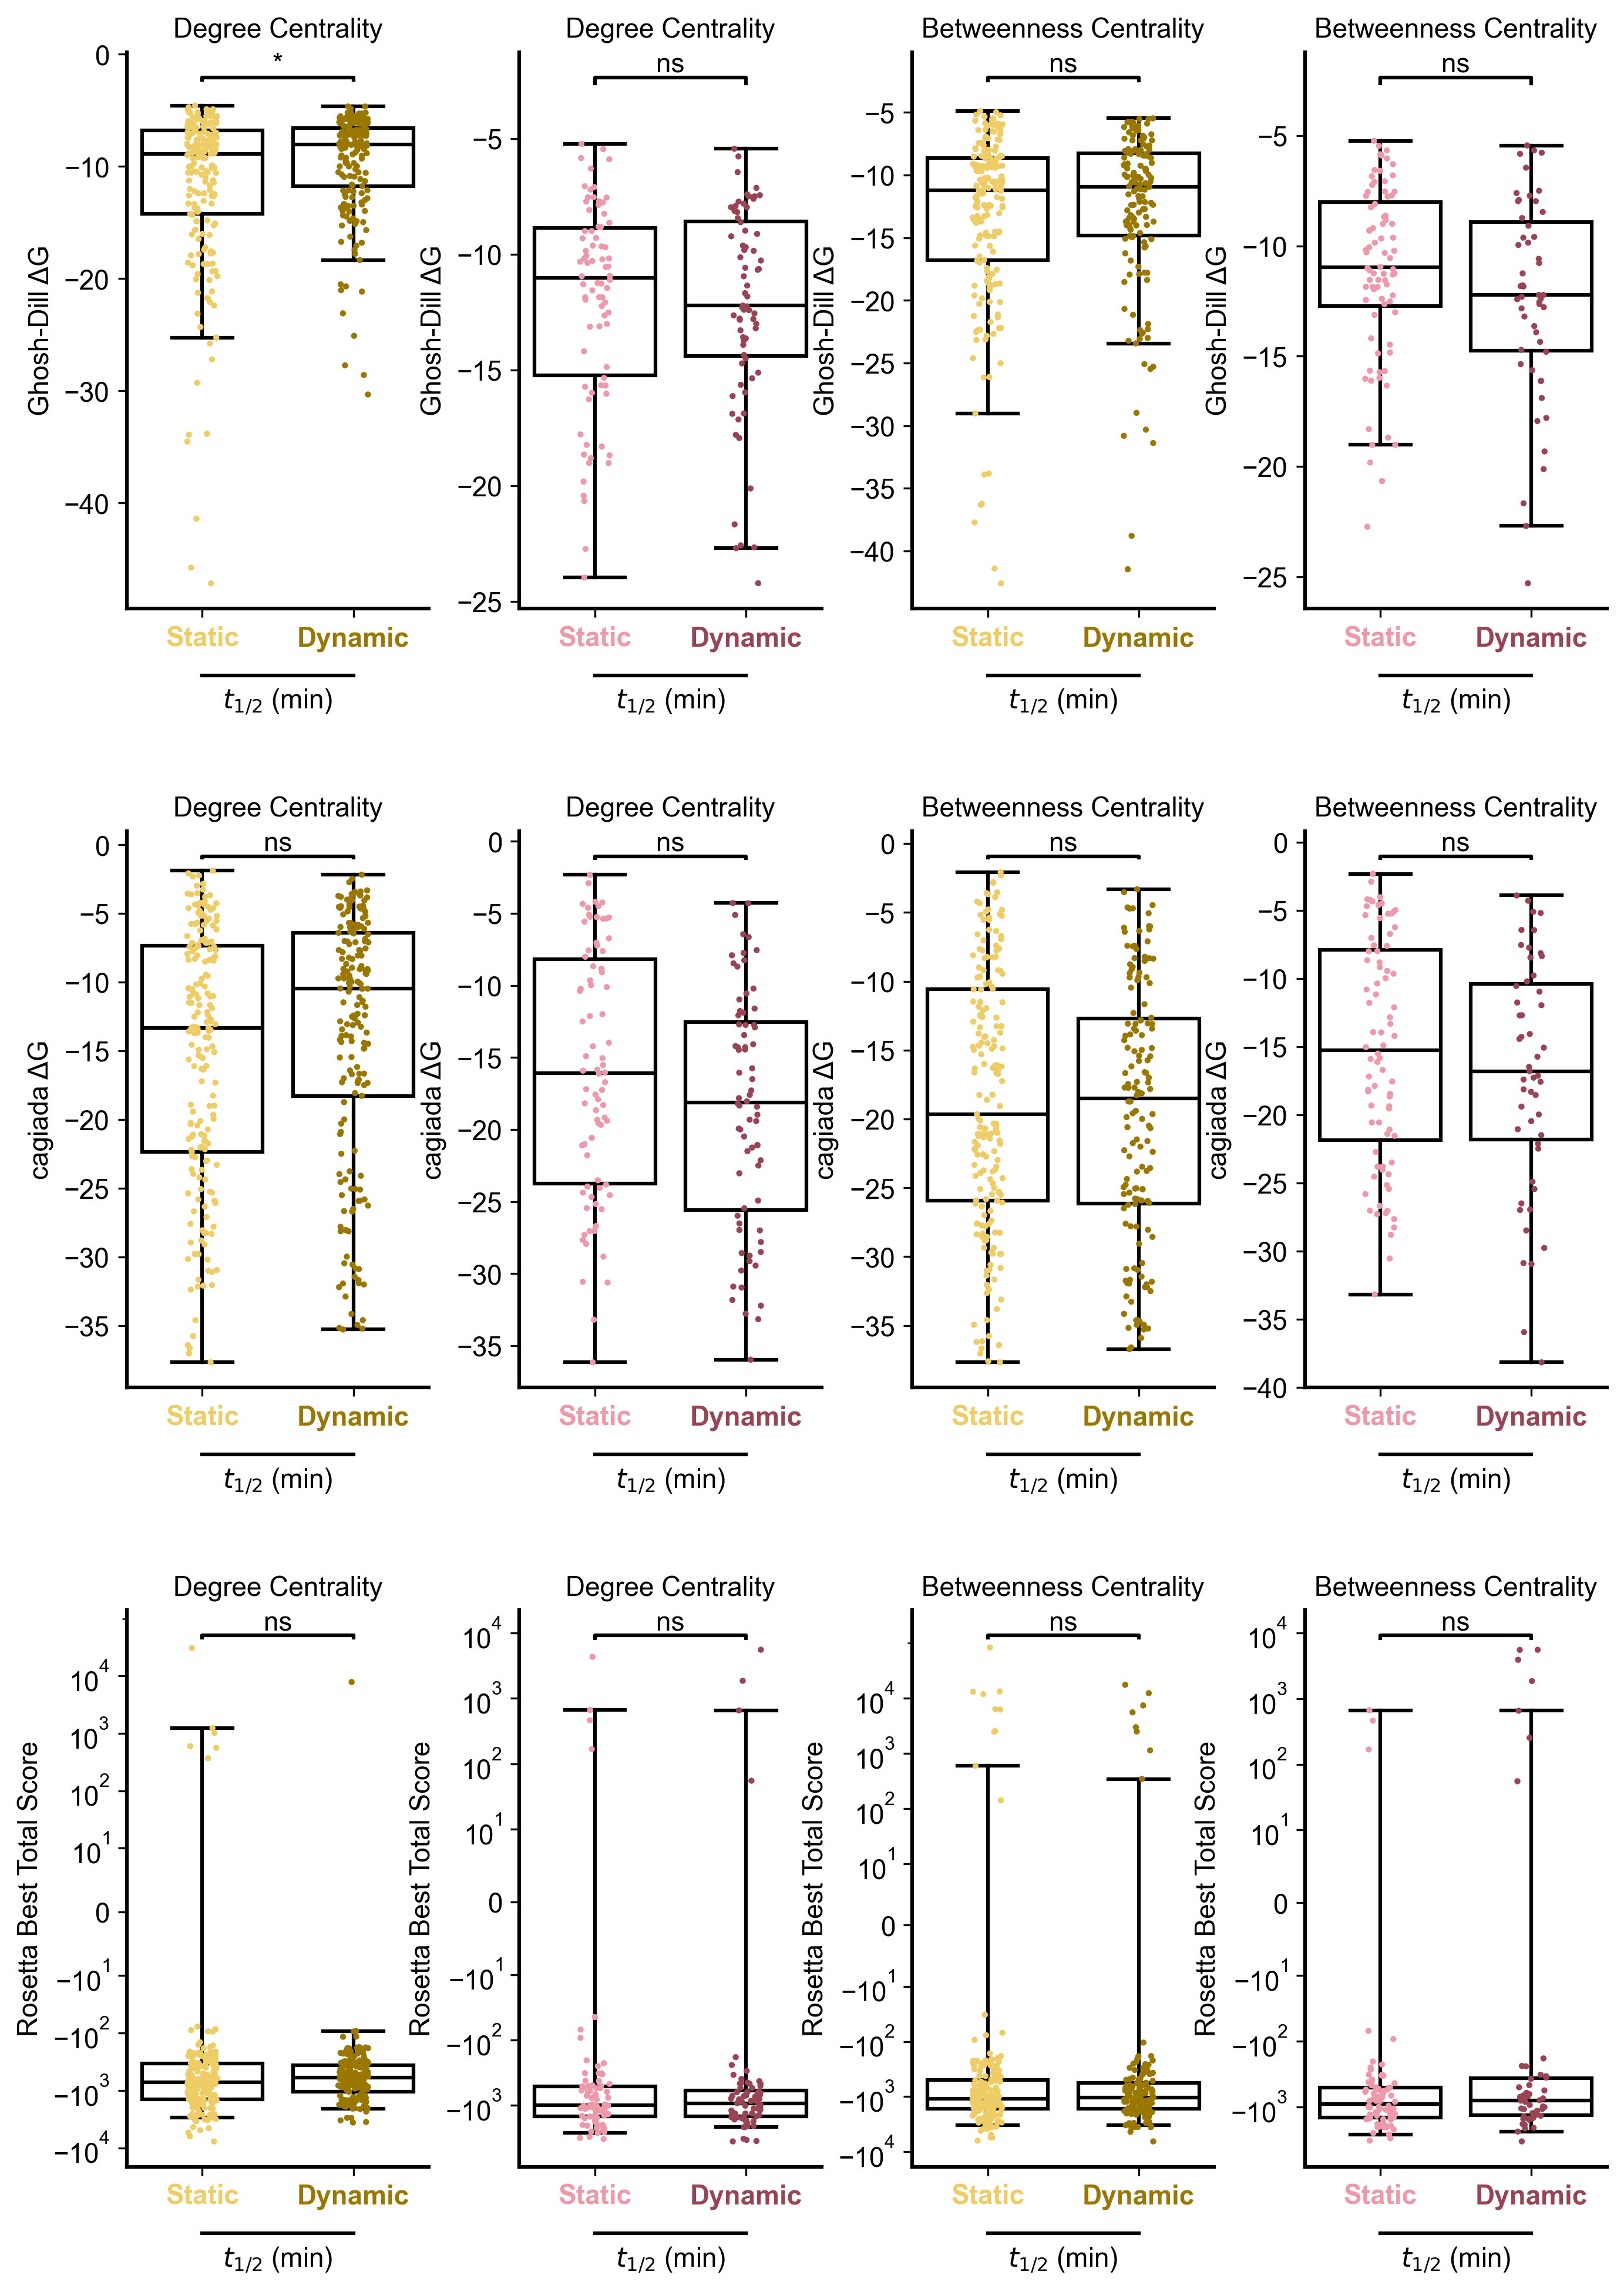

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import os
from matplotlib.patches import Patch
import warnings
import matplotlib.ticker as ticker
# ===== Global matplotlib settings =====
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
# ===== Function to plot single hub in complex stability boxplot =====
def test_hub_complex_stability_boxplot_single(selected_columns, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=True, print_stats=True, show_legend=True):
    warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")
    # === Filter to hubs only ===
    hub_df = selected_columns[selected_columns[col] >= 90].copy()
    hub_df['complex_type'] = np.where(hub_df['in_complex'].astype(bool), 'Static', 'Dynamic')
 
    # === Compute stats ===
    static_hub = hub_df[hub_df['complex_type'] == 'Static'][stability_col].dropna()
    dynamic_hub = hub_df[hub_df['complex_type'] == 'Dynamic'][stability_col].dropna()
 
    stat, p = (mannwhitneyu(static_hub, dynamic_hub, alternative='two-sided') if len(static_hub) > 0 and len(dynamic_hub) > 0 else (np.nan, 1.0))
    ks_stat, ks_p = (ks_2samp(static_hub, dynamic_hub) if len(static_hub) > 0 and len(dynamic_hub) > 0 else (np.nan, 1.0))
 
    if print_stats:
        print(f"\n=== Counts for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        print(f"Static: {len(static_hub)}")
        print(f"Dynamic: {len(dynamic_hub)}")
     
        print(f"\n=== Percentage Differences for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        static_median = np.median(static_hub)
        dynamic_median = np.median(dynamic_hub)
        percentage = ((static_median - dynamic_median) / dynamic_median) * 100 if dynamic_median != 0 else 0
        print(f"Static Hubs are {percentage:.2f}% greater than Dynamic Hubs (medians: {static_median:.2f} vs {dynamic_median:.2f})")
     
        print(f"\n=== Mann-Whitney U Test for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        print(f"Static vs Dynamic: U={stat:.2f}, p={p:.4g}")
        print(f"\n=== Kolmogorov-Smirnov Tests for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        print(f"Static vs Dynamic: KS={ks_stat:.2f}, p={ks_p:.4g}, n1={len(static_hub)}, n2={len(dynamic_hub)}")
 
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
 
    # === Set color scheme ===
    if network_name == 'Y2H':
        palette = {'Static': '#EE99AA', 'Dynamic': '#994455'} # Light pink for Static Hubs, dark pink for Dynamic Hubs
    else: # IPMS/MS
        palette = {'Static': '#EECC66', 'Dynamic': '#997700'} # Light yellow for Static Hubs, dark yellow for Dynamic Hubs
    bottom_color = 'black'
 
    # === Plot: swarm overlay + Boxplot ===
    sns.stripplot(
        data=hub_df,
        x='complex_type',
        y=stability_col,
        order=['Static', 'Dynamic'],
        hue='complex_type',
        palette=palette,
        size=2.5,
        alpha=1.0,
        jitter=True,
        dodge=False,
        ax=ax
    )
    sns.boxplot(
        data=hub_df,
        x='complex_type',
        y=stability_col,
        order=['Static', 'Dynamic'],
        hue='complex_type',
        palette=palette,
        ax=ax,
        width=0.8,
        fliersize=2,
        linewidth=1.5,
        showcaps=True,
        showfliers=False,
        dodge=False,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5}
    )
    for artist in ax.patches:
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_ylabel(stability_name)
    ax.set_xlabel('')
    ax.set_xticklabels(['Static', 'Dynamic'], rotation=0, ha='center')
    ax.set_xticks([0, 1])
    # Color the x-axis labels to match the palette
    labels = ax.get_xticklabels()
    labels[0].set_color(palette['Static']) # Light shade for Static Hubs
    labels[1].set_color(palette['Dynamic']) # Dark shade for Dynamic Hubs
    for label in labels:
        label.set_fontweight('bold')
    # === Legend formatting ===
    if show_legend:
        ordered_labels = ['Static', 'Dynamic']
        ordered_handles = [
            Patch(facecolor=palette[label], edgecolor='black', linewidth=1.5, label=label)
            for label in ordered_labels
        ]
        leg = ax.legend(
            ordered_handles,
            ordered_labels,
            title=None,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.3),
            ncol=2,
            fontsize=10,
            frameon=False
        )
        if leg is not None:
            leg.get_frame().set_linewidth(0)
            leg.get_frame().set_alpha(0.0)
    # Set symlog scale for Rosetta with custom ticks
    if stability_name == 'Rosetta Best Total Score':
        ax.set_yscale('symlog', linthresh=10)
        ax.set_yticks([-10000, -1000, -100, -10, 0, 10, 100, 1000, 10000])
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    # === Add significance bar ===
    def add_significance_bar(x1, x2, y, p_value, ax):
        height = y
        delta = 0.1 * abs(height)
        ax.plot([x1, x1, x2, x2], [height, height + delta, height + delta, height], lw=1.5, c='black')
        stars = 'ns' if p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, height + delta, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11)
 
    max_y = hub_df[stability_col].max()
    y_start = max_y * 1.5 if max_y > 0 else max_y + abs(max_y) * 0.5
    add_significance_bar(0, 1, y_start, p, ax)
 
    # === Bottom line + annotation ===
    ax.plot([0, 1], [-0.12, -0.12], color=bottom_color, lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.14, r'$t_{1/2}$ (min)', ha='center', va='top',
            fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(),
            color='black')
 
    ax.set_title(f'{metric_name}')
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
 
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        # Use label 5D for this figure panel
        figure_label = "5D"
        # Persistent counter across calls
        if not hasattr(test_hub_complex_stability_boxplot_single, "counter"):
            test_hub_complex_stability_boxplot_single.counter = 1
        # New filename format: 5D.1.svg, 5D.2.svg, ...
        save_path = os.path.join(save_dir, f"{figure_label}.{test_hub_complex_stability_boxplot_single.counter}.svg")
        # Increment for next call
        test_hub_complex_stability_boxplot_single.counter += 1
        # Save
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
       
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())
# ===== Example: loop over all four combinations and three stability metrics =====
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE5"
combinations = [
    ('MS_degree_centrality_percentile', 'IPMS', '#DDAA33', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', '#BB5566', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', '#DDAA33', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', '#BB5566', 'Betweenness Centrality')
]
stability_metrics = [
    ('Ghosh-Dill-dG', 'Ghosh-Dill ΔG'),
    ('cagiada-dG', 'cagiada ΔG'),
    ('Rosetta_best_total_score', 'Rosetta Best Total Score')
]
# Save individual plots (with stats printed)
for stability_col, stability_name in stability_metrics:
    for col, network_name, color, metric_name in combinations:
        test_hub_complex_stability_boxplot_single(filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=False, print_stats=True, show_legend=False)
# Optional: Display in a 3x4 grid (one row per stability metric, no additional prints)
fig, axs = plt.subplots(3, 4, figsize=(12, 15)) # 3 stability metrics x 4 combinations
for i, (stability_col, stability_name) in enumerate(stability_metrics):
    for j, (col, network_name, color, metric_name) in enumerate(combinations):
        test_hub_complex_stability_boxplot_single(
            filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name,
            ax=axs[i, j], save=False, show=False, print_stats=False, show_legend=False
        )
plt.subplots_adjust(left=0.15, bottom=0.15, right=0.85, top=0.95, hspace=0.4, wspace=0.3)
plt.show()


=== Counts for IPMS Degree Centrality - Meltome Melting Point (°C) (hubs only) ===
Static: 129
Dynamic: 138

=== Percentage Differences for IPMS Degree Centrality - Meltome Melting Point (°C) (hubs only) ===
Static Hubs are 6.95% greater than Dynamic Hubs (medians: 47.38 vs 44.30)

=== Mann-Whitney U Test for IPMS Degree Centrality - Meltome Melting Point (°C) (hubs only) ===
Static vs Dynamic: U=10971.50, p=0.001027

=== Kolmogorov-Smirnov Tests for IPMS Degree Centrality - Meltome Melting Point (°C) (hubs only) ===
Static vs Dynamic: KS=0.22, p=0.003024, n1=129, n2=138

=== Counts for Y2H Degree Centrality - Meltome Melting Point (°C) (hubs only) ===
Static: 32
Dynamic: 39

=== Percentage Differences for Y2H Degree Centrality - Meltome Melting Point (°C) (hubs only) ===
Static Hubs are -1.06% greater than Dynamic Hubs (medians: 49.52 vs 50.05)

=== Mann-Whitney U Test for Y2H Degree Centrality - Meltome Melting Point (°C) (hubs only) ===
Static vs Dynamic: U=492.00, p=0.1286

=== Ko

/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key


=== Counts for Y2H Betweenness Centrality - Meltome Melting Point (°C) (hubs only) ===
Static: 27
Dynamic: 25

=== Percentage Differences for Y2H Betweenness Centrality - Meltome Melting Point (°C) (hubs only) ===
Static Hubs are -1.20% greater than Dynamic Hubs (medians: 49.45 vs 50.05)

=== Mann-Whitney U Test for Y2H Betweenness Centrality - Meltome Melting Point (°C) (hubs only) ===
Static vs Dynamic: U=291.50, p=0.4046

=== Kolmogorov-Smirnov Tests for Y2H Betweenness Centrality - Meltome Melting Point (°C) (hubs only) ===
Static vs Dynamic: KS=0.22, p=0.4547, n1=27, n2=25


/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/goel107/.conda/envs/ml_class/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key

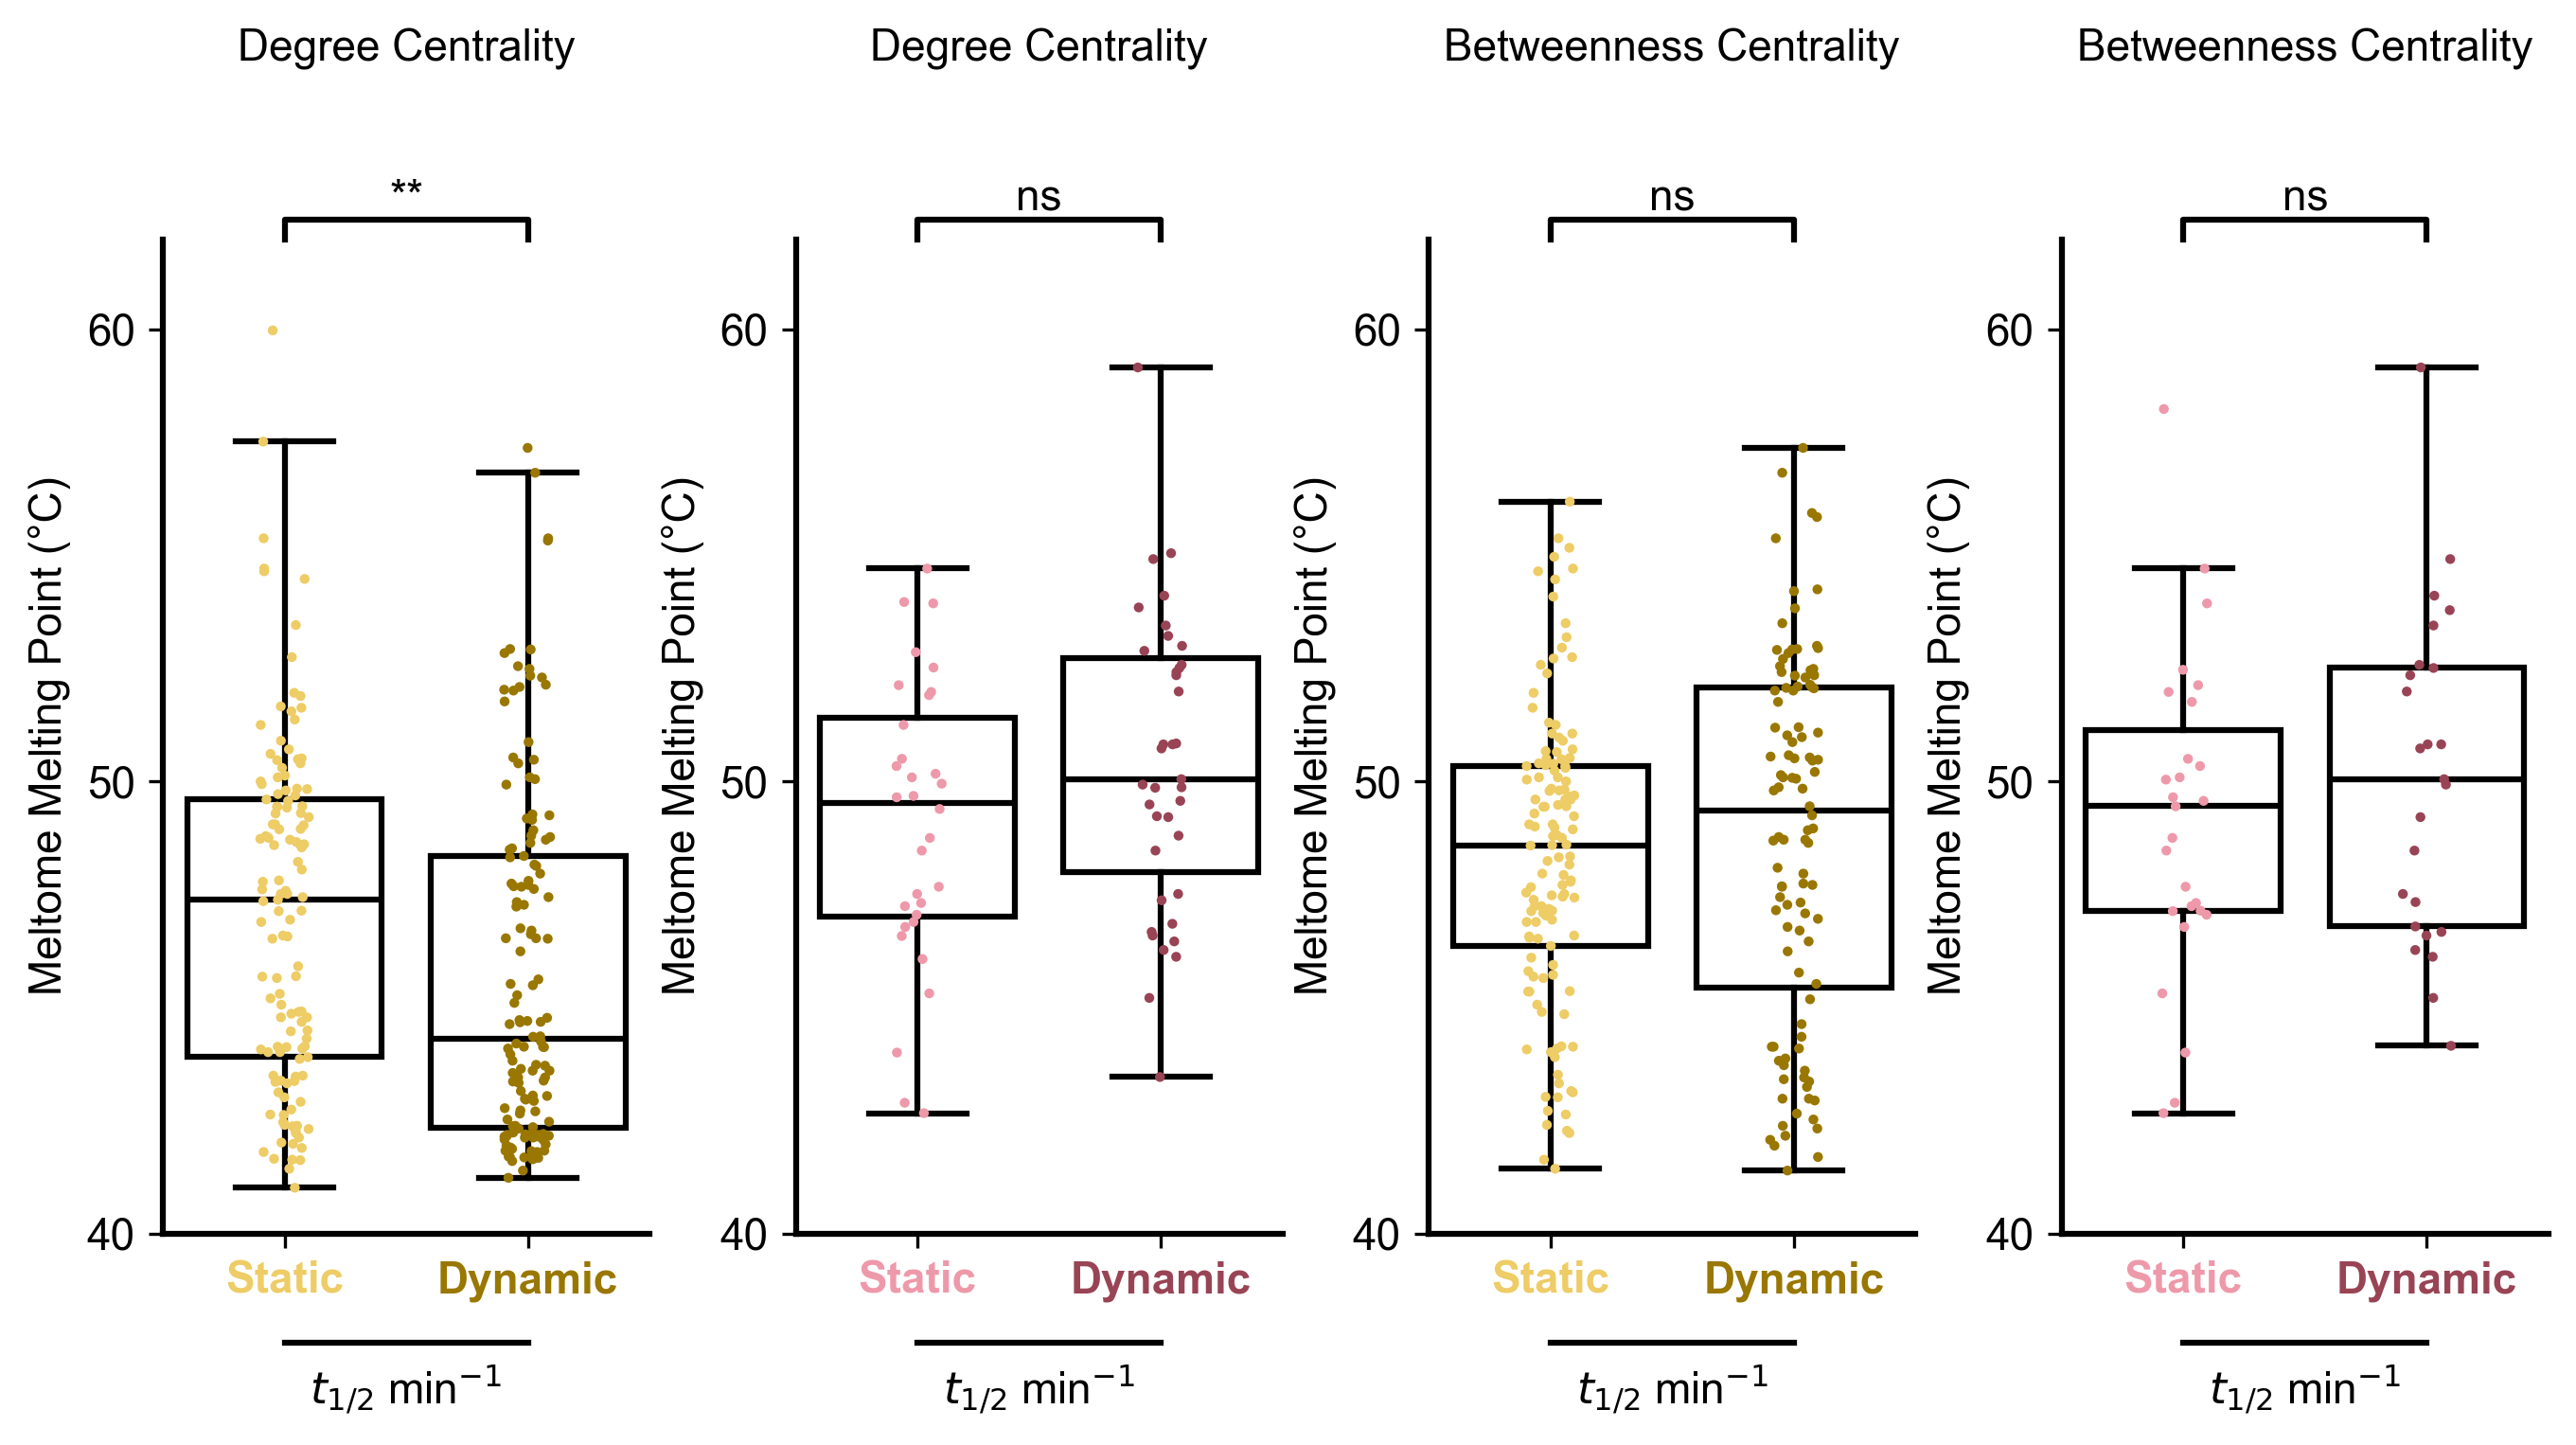

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ks_2samp
import os
from matplotlib.patches import Patch
from matplotlib.transforms import blended_transform_factory
import warnings
# ===== Global matplotlib settings =====
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 300
# ===== Function to plot single hub in complex stability boxplot =====
def test_hub_complex_stability_boxplot_single(selected_columns, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=True, print_stats=True, show_legend=True):
    warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")
   
    # === Filter to hubs only ===
    hub_df = selected_columns[selected_columns[col] >= 90].copy()
    hub_df['complex_type'] = np.where(hub_df['in_complex'].astype(bool), 'Static', 'Dynamic')
   
    # === Compute stats ===
    static_hub = hub_df[hub_df['complex_type'] == 'Static'][stability_col].dropna()
    dynamic_hub = hub_df[hub_df['complex_type'] == 'Dynamic'][stability_col].dropna()
   
    stat, p = (mannwhitneyu(static_hub, dynamic_hub, alternative='two-sided') if len(static_hub) > 0 and len(dynamic_hub) > 0 else (np.nan, 1.0))
    ks_stat, ks_p = (ks_2samp(static_hub, dynamic_hub) if len(static_hub) > 0 and len(dynamic_hub) > 0 else (np.nan, 1.0))
   
    if print_stats:
        print(f"\n=== Counts for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        print(f"Static: {len(static_hub)}")
        print(f"Dynamic: {len(dynamic_hub)}")
       
        print(f"\n=== Percentage Differences for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        static_median = np.median(static_hub)
        dynamic_median = np.median(dynamic_hub)
        percentage = ((static_median - dynamic_median) / dynamic_median) * 100 if dynamic_median != 0 else 0
        print(f"Static Hubs are {percentage:.2f}% greater than Dynamic Hubs (medians: {static_median:.2f} vs {dynamic_median:.2f})")
       
        print(f"\n=== Mann-Whitney U Test for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        print(f"Static vs Dynamic: U={stat:.2f}, p={p:.4g}")
        print(f"\n=== Kolmogorov-Smirnov Tests for {network_name} {metric_name} - {stability_name} (hubs only) ===")
        print(f"Static vs Dynamic: KS={ks_stat:.2f}, p={ks_p:.4g}, n1={len(static_hub)}, n2={len(dynamic_hub)}")
   
    # === Create ax if not provided ===
    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
        fig.subplots_adjust(top=0.8)
   
    # === Set color scheme ===
    if network_name == 'Y2H':
        palette = {'Static': '#EE99AA', 'Dynamic': '#994455'} # Light pink for Static Hubs, dark pink for Dynamic Hubs
    else: # IPMS/MS
        palette = {'Static': '#EECC66', 'Dynamic': '#997700'} # Light yellow for Static Hubs, dark yellow for Dynamic Hubs
    bottom_color = 'black'
   
    # === Plot: swarm overlay + Boxplot ===
    sns.stripplot(
        data=hub_df,
        x='complex_type',
        y=stability_col,
        order=['Static', 'Dynamic'],
        hue='complex_type',
        palette=palette,
        size=2.5,
        alpha=1.0,
        jitter=True,
        dodge=False,
        ax=ax
    )
    sns.boxplot(
        data=hub_df,
        x='complex_type',
        y=stability_col,
        order=['Static', 'Dynamic'],
        hue='complex_type',
        palette=palette,
        ax=ax,
        width=0.8,
        fliersize=2,
        linewidth=1.5,
        showcaps=True,
        showfliers=False,
        dodge=False,
        boxprops={'edgecolor': 'black'},
        whiskerprops={'color': 'black', 'linewidth': 1.5},
        capprops={'color': 'black', 'linewidth': 1.5},
        medianprops={'color': 'black', 'linewidth': 1.5}
    )
    for artist in ax.patches:
        artist.set_facecolor('none')
        artist.set_edgecolor('black')
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_ylabel(stability_name)
    ax.set_xlabel('')
    ax.set_xticklabels(['Static', 'Dynamic'], rotation=0, ha='center')
    ax.set_xticks([0, 1])
    # Color the x-axis labels to match the palette
    labels = ax.get_xticklabels()
    labels[0].set_color(palette['Static']) # Light shade for Static Hubs
    labels[1].set_color(palette['Dynamic']) # Dark shade for Dynamic Hubs
    for label in labels:
        label.set_fontweight('bold')
   
    # Set y-axis limit and ticks for meltome-melting-point
    if stability_col == 'meltome-melting-point':
        ax.set_ylim(40, 62)
        ax.set_yticks([40, 50, 60])
   
    # === Legend formatting ===
    if show_legend:
        ordered_labels = ['Static', 'Dynamic']
        ordered_handles = [
            Patch(facecolor=palette[label], edgecolor='black', linewidth=1.5, label=label)
            for label in ordered_labels
        ]
        leg = ax.legend(
            ordered_handles,
            ordered_labels,
            title=None,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.3),
            ncol=2,
            fontsize=10,
            frameon=False
        )
        if leg is not None:
            leg.get_frame().set_linewidth(0)
            leg.get_frame().set_alpha(0.0)
   
    # === Add significance bar ===
    def add_significance_bar(x1, x2, p_value, ax):
        height = 1.0  # Fixed in axes coords, below title
        delta = 0.02
        trans = blended_transform_factory(ax.transData, ax.transAxes)
        ax.plot([x1, x1, x2, x2], [height, height + delta, height + delta, height], lw=1.5, c='black', transform=trans, clip_on=False)
        stars = 'ns' if p_value >= 0.05 else '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*'
        ax.text((x1 + x2) * 0.5, height + delta, stars, ha='center', va='bottom', fontfamily='Arial', fontsize=11, transform=trans)
   
    add_significance_bar(0, 1, p, ax)
   
    # Add manual title above sig bar
    ax.text(0.5, 1.17, metric_name, transform=ax.transAxes, ha='center', va='bottom', fontsize=11)
   
    # === Bottom line + annotation ===
    ax.plot([0, 1], [-0.11, -0.11], color=bottom_color, lw=1.5, clip_on=False, transform=ax.get_xaxis_transform())
    ax.text(0.5, -0.13, r'$t_{1/2}$ min$^{-1}$', ha='center', va='top',
            fontfamily='Arial', fontsize=11, transform=ax.get_xaxis_transform(),
            color='black')
   
    sns.despine(ax=ax)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
   
    # === Save + show ===
    if save:
        os.makedirs(save_dir, exist_ok=True)
        # Use label 5D for this figure panel
        figure_label = "5D"
        # Persistent counter across calls
        if not hasattr(test_hub_complex_stability_boxplot_single, "counter"):
            test_hub_complex_stability_boxplot_single.counter = 13
        # New filename format: 5D.1.svg, 5D.2.svg, ...
        save_path = os.path.join(save_dir, f"{figure_label}.{test_hub_complex_stability_boxplot_single.counter}.svg")
        # Increment for next call
        test_hub_complex_stability_boxplot_single.counter += 1
        # Save
        ax.get_figure().savefig(save_path, dpi=300, bbox_inches='tight')
       
    if standalone:
        if show:
            plt.show()
        else:
            plt.close(ax.get_figure())
# ===== Example: loop over all four combinations and one stability metric =====
save_dir = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/FIGURE5"
combinations = [
    ('MS_degree_centrality_percentile', 'IPMS', '#DDAA33', 'Degree Centrality'),
    ('Y2H_degree_centrality_percentile', 'Y2H', '#BB5566', 'Degree Centrality'),
    ('MS_betweenness_centrality_percentile', 'IPMS', '#DDAA33', 'Betweenness Centrality'),
    ('Y2H_betweenness_centrality_percentile', 'Y2H', '#BB5566', 'Betweenness Centrality')
]
stability_metrics = [
    ('meltome-melting-point', 'Meltome Melting Point (°C)')
]
# Filter for proteins with 'meltome-fit-R2' > 0.9
selected_columns = selected_columns[selected_columns['meltome-fit-R2'] >= 0.9]
# Save individual plots (with stats printed)
for stability_col, stability_name in stability_metrics:
    for col, network_name, color, metric_name in combinations:
        test_hub_complex_stability_boxplot_single(filtered_df, col, network_name, color, save_dir, metric_name, stability_col, stability_name, ax=None, save=True, show=False, print_stats=True, show_legend=False)
# Optional: Display in a 1x4 grid (one row for the stability metric, no additional prints)
fig, axs = plt.subplots(1, 4, figsize=(12, 5)) # 1 stability metric x 4 combinations
for j, (col, network_name, color, metric_name) in enumerate(combinations):
    test_hub_complex_stability_boxplot_single(
        filtered_df, col, network_name, color, save_dir, metric_name, stability_metrics[0][0], stability_metrics[0][1],
        ax=axs[j], save=False, show=False, print_stats=False, show_legend=False
    )
plt.subplots_adjust(left=0.15, bottom=0.15, right=0.85, top=0.85, hspace=0.4, wspace=0.3)
plt.show()